# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

/export/home/natarajanpr/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import geopandas as gpd

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.2.6
pandas version: 2.2.2
matplotlib version: 3.8.4
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
data_dir = 'Datasets and Dictionary/trip_records'
file_list = sorted([f for f in os.listdir(data_dir) if f.endswith('.parquet')])
sampled_list = []

# sample 5% per date-hour group from each monthly file
for file_name in file_list:
    try:
        temp_df = pd.read_parquet(os.path.join(data_dir, file_name))
        temp_df['pickup_date'] = temp_df['tpep_pickup_datetime'].dt.date
        temp_df['pickup_hour'] = temp_df['tpep_pickup_datetime'].dt.hour
        monthly_sample = temp_df.groupby(['pickup_date', 'pickup_hour'], group_keys=False).sample(frac=0.05, random_state=42)
        sampled_list.append(monthly_sample)
        del temp_df
        print(f"done: {file_name}")
    except Exception as e:
        print(f"error {file_name}: {e}")

master_df = pd.concat(sampled_list, ignore_index=True)
print(f"total rows: {len(master_df)}")
master_df.head()

done: 2023-1.parquet


done: 2023-10.parquet


done: 2023-11.parquet


done: 2023-12.parquet


done: 2023-2.parquet


...

done: 2023-6.parquet


done: 2023-7.parquet


done: 2023-8.parquet


done: 2023-9.parquet
total rows: 1896400


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,1,...,0.5,3.00,0.0,1.0,18.00,2.5,0.0,2022-12-31,23,NaN
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,NaN,0.00,NaN,None,68,45,0,...,0.5,0.00,0.0,1.0,39.30,NaN,NaN,2023-01-01,0,NaN
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,2,...,0.5,0.00,0.0,1.0,12.20,2.5,0.0,2023-01-01,0,NaN
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,1,...,0.5,3.05,0.0,1.0,15.25,2.5,0.0,2023-01-01,0,NaN
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,1,...,0.5,4.60,0.0,1.0,23.10,2.5,0.0,2023-01-01,0,NaN


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [6]:
master_df.to_parquet('sampled_master_2023.parquet')
print(f"saved {len(master_df)} rows")

saved 1896400 rows


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [7]:
df = pd.read_parquet('sampled_master_2023.parquet')
print(f"rows: {len(df)}")
df.head()

rows: 1896400


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,1,...,0.5,3.00,0.0,1.0,18.00,2.5,0.0,2022-12-31,23,NaN
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,NaN,0.00,NaN,None,68,45,0,...,0.5,0.00,0.0,1.0,39.30,NaN,NaN,2023-01-01,0,NaN
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,2,...,0.5,0.00,0.0,1.0,12.20,2.5,0.0,2023-01-01,0,NaN
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,1,...,0.5,3.05,0.0,1.0,15.25,2.5,0.0,2023-01-01,0,NaN
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,1,...,0.5,4.60,0.0,1.0,23.10,2.5,0.0,2023-01-01,0,NaN


In [8]:
 df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,1,...,0.5,3.00,0.0,1.0,18.00,2.5,0.0,2022-12-31,23,NaN
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,NaN,0.00,NaN,None,68,45,0,...,0.5,0.00,0.0,1.0,39.30,NaN,NaN,2023-01-01,0,NaN
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,2,...,0.5,0.00,0.0,1.0,12.20,2.5,0.0,2023-01-01,0,NaN
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,1,...,0.5,3.05,0.0,1.0,15.25,2.5,0.0,2023-01-01,0,NaN
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,1,...,0.5,4.60,0.0,1.0,23.10,2.5,0.0,2023-01-01,0,NaN


In [9]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

In [10]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,Airport_fee
count,1.896400e+06,1896400,1896400,1.831439e+06,1.896400e+06,1.831439e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.831439e+06,148441.000000,1.896400e+06,1.682998e+06
mean,1.735933e+00,2023-07-02 19:59:52.252299,2023-07-02 20:17:19.694492,1.369732e+00,3.966358e+00,1.649111e+00,1.652374e+02,1.640294e+02,1.163460e+00,1.990621e+01,1.583205e+00,4.952479e-01,3.557074e+00,5.998480e-01,9.990095e-01,2.898514e+01,2.308118e+00,0.110642,1.426504e+01,1.466242e-01
min,1.000000e+00,2022-12-31 23:36:04,2022-12-31 23:43:31,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-2.500000e+00,-5.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-6.500000e+00,-2.500000e+00,-1.250000,0.000000e+00,-1.750000e+00
25%,1.000000e+00,2023-04-02 16:11:35.750000,2023-04-02 16:33:11.750000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000,1.100000e+01,0.000000e+00
50%,2.000000e+00,2023-06-27 15:46:22,2023-06-27 16:08:19,1.000000e+00,1.800000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000,1.500000e+01,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:51,2023-10-06 19:56:09.750000,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.250000e+01,2.500000e+00,5.000000e-01,4.450000e+00,0.000000e+00,1.000000e+00,3.100000e+01,2.500000e+00,0.000000,1.900000e+01,0.000000e+00
max,6.000000e+00,2023-12-31 23:56:33,2024-01-01 13:29:31,9.000000e+00,1.439264e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.116700e+03,9.638000e+01,5.750000e+00,4.100000e+02,8.355000e+01,1.000000e+00,1.120700e+03,2.500000e+00,1.250000,2.300000e+01,1.750000e+00
std,4.465162e-01,NaN,NaN,8.928760e-01,1.713594e+02,7.481852e+00,6.398685e+01,6.987281e+01,5.077709e-01,1.836839e+01,1.830707e+00,4.927953e-02,4.085411e+00,2.186720e+00,3.088591e-02,2.295079e+01,6.657842e-01,0.355170,5.807381e+00,4.744715e-01


#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [11]:
df = df.reset_index(drop=True)
df.drop(columns=['pickup_date', 'pickup_hour', 'store_and_fwd_flag'], inplace=True, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           int64         
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  airport_fee            float64       
 18  Airport_fee           

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [12]:
col_groups = {}
for col in df.columns:
    col_groups.setdefault(col.lower(), []).append(col)

# merge columns that differ only by capitalisation (e.g. airport_fee vs Airport_fee)
for low_name, cols in col_groups.items():
    if len(cols) > 1:
        counts = {c: df[c].count() for c in cols}
        best_col = max(counts, key=counts.get)
        df.drop(columns=[c for c in cols if c != best_col], inplace=True)
        df.rename(columns={best_col: low_name}, inplace=True)
        print(f"merged: {cols} -> {low_name}")

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

merged: ['airport_fee', 'Airport_fee'] -> airport_fee
['vendorid', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [13]:


monetary_columns = ['fare_amount', 'extra', 'mta_tax', 'tip_amount',
    'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'airport_fee']

for col in monetary_columns:
  if col in df.columns:
    count = (df[col] < 0).sum()
    if count > 0:
      df[col] = df[col].abs()
      print(f"Column '{col}' has {count} negative values.")
    else:
      print(f"Column '{col}' has no negative values.")

Column 'fare_amount' has no negative values.


Column 'extra' has 2 negative values.
Column 'mta_tax' has 80 negative values.
Column 'tip_amount' has no negative values.
Column 'tolls_amount' has no negative values.
Column 'improvement_surcharge' has 88 negative values.
Column 'total_amount' has 88 negative values.
Column 'congestion_surcharge' has 56 negative values.
Column 'airport_fee' has 22 negative values.


Did you notice something different in the `RatecodeID` column for above records?

In [14]:
print(df['ratecodeid'].value_counts())
print("unique values:", sorted(df['ratecodeid'].unique()))

ratecodeid
1.0     1727956
2.0       72513
99.0      10724
5.0       10528
3.0        5928
4.0        3788
6.0           2
Name: count, dtype: int64
unique values: [np.float64(1.0), np.float64(nan), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(99.0)]


In [15]:
for col in df.columns:
    # Check if the column is numeric before checking for negative values
    if pd.api.types.is_numeric_dtype(df[col]):
        negative_values_count = (df[col] < 0).sum()
        if negative_values_count > 0:
            print(f"Column '{col}' still has {negative_values_count} negative values after previous correction.")
        else:
            print(f"Column '{col}' has no negative values.")
    else:
        print(f"Column '{col}' is not a numeric type, skipping negative value check.")

Column 'vendorid' has no negative values.
Column 'tpep_pickup_datetime' is not a numeric type, skipping negative value check.
Column 'tpep_dropoff_datetime' is not a numeric type, skipping negative value check.
Column 'passenger_count' has no negative values.
Column 'trip_distance' has no negative values.
Column 'ratecodeid' has no negative values.
Column 'pulocationid' has no negative values.
Column 'dolocationid' has no negative values.
Column 'payment_type' has no negative values.
Column 'fare_amount' has no negative values.


Column 'extra' has no negative values.
Column 'mta_tax' has no negative values.
Column 'tip_amount' has no negative values.
Column 'tolls_amount' has no negative values.


Column 'improvement_surcharge' has no negative values.
Column 'total_amount' has no negative values.
Column 'congestion_surcharge' has no negative values.
Column 'airport_fee' has no negative values.


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [16]:
# Find the proportion of missing values in each column

missing_matrix = (df.isna().sum() / len(df)) * 100
missing_matrix

vendorid                  0.000000
tpep_pickup_datetime      0.000000
tpep_dropoff_datetime     0.000000
passenger_count           3.425490
trip_distance             0.000000
ratecodeid                3.425490
pulocationid              0.000000
dolocationid              0.000000
payment_type              0.000000
fare_amount               0.000000
extra                     0.000000
mta_tax                   0.000000
tip_amount                0.000000
tolls_amount              0.000000
improvement_surcharge     0.000000
total_amount              0.000000
congestion_surcharge      3.425490
airport_fee              11.253006
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [17]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
ps = df[df['passenger_count'].isna()]
ps
df['passenger_count'] = df['passenger_count'].fillna(1)

In [18]:
df[df['passenger_count'].isna()]

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you find zeroes in passenger_count? Handle these.

In [19]:
df['passenger_count'] = df['passenger_count'].replace(0, 1)
print("zeros remaining:", (df['passenger_count'] == 0).sum())

zeros remaining: 0


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [20]:
# Fix missing values in 'RatecodeID'
df['ratecodeid'] = df['ratecodeid'].fillna(df['ratecodeid'].mode()[0])
df['ratecodeid'] = df['ratecodeid'].astype(int)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [21]:
# handle null values in congestion_surcharge
#its just 3% of whole data, we can consider that might not entered congestionzone, we can keep it as 0
df['congestion_surcharge']= df['congestion_surcharge'].fillna(0.0)


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [22]:
# Handle any remaining missing values
# Fill with 0.0 assuming no airport pickup fee for the unrecorded 11% of trips
df['airport_fee']= df['airport_fee'].fillna(0.0)


### **2.3** Handling Outliers

<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [23]:
df.describe()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,1.896400e+06,1896400,1896400,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
mean,1.735933e+00,2023-07-02 19:59:52.252299,2023-07-02 20:17:19.694492,1.372487e+00,3.966358e+00,1.626876e+00,1.652374e+02,1.640294e+02,1.163460e+00,1.990621e+01,1.583209e+00,4.952900e-01,3.557074e+00,5.998480e-01,9.991024e-01,2.898547e+01,2.229201e+00,1.301636e-01
min,1.000000e+00,2022-12-31 23:36:04,2022-12-31 23:43:31,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:11:35.750000,2023-04-02 16:33:11.750000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-27 15:46:22,2023-06-27 16:08:19,1.000000e+00,1.800000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:51,2023-10-06 19:56:09.750000,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.250000e+01,2.500000e+00,5.000000e-01,4.450000e+00,0.000000e+00,1.000000e+00,3.100000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2023-12-31 23:56:33,2024-01-01 13:29:31,9.000000e+00,1.439264e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.116700e+03,9.638000e+01,5.750000e+00,4.100000e+02,8.355000e+01,1.000000e+00,1.120700e+03,2.500000e+00,1.750000e+00
std,4.465162e-01,NaN,NaN,8.647379e-01,1.713594e+02,7.353538e+00,6.398685e+01,6.987281e+01,5.077709e-01,1.836839e+01,1.830703e+00,4.885372e-02,4.085411e+00,2.186720e+00,2.772183e-02,2.295037e+01,7.769588e-01,4.493628e-01


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [24]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]
df

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1,43,141,1,10.0,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,1.0,0.00,1,68,45,0,35.3,0.0,0.5,0.00,0.0,1.0,39.30,0.0,0.0
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1,144,211,2,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1,79,107,1,7.2,1.0,0.5,3.05,0.0,1.0,15.25,2.5,0.0
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1,48,238,1,13.5,3.5,0.5,4.60,0.0,1.0,23.10,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896395,2,2023-09-30 23:51:38,2023-09-30 23:53:08,1.0,0.46,1,239,238,2,4.4,1.0,0.5,0.00,0.0,1.0,9.40,2.5,0.0
1896396,2,2023-09-30 23:14:40,2023-09-30 23:35:31,1.0,2.80,1,249,50,1,19.1,1.0,0.5,2.00,0.0,1.0,26.10,2.5,0.0
1896397,2,2023-09-30 23:23:52,2023-09-30 23:50:41,1.0,5.68,1,164,256,1,28.9,1.0,0.5,6.78,0.0,1.0,40.68,2.5,0.0
1896398,2,2023-09-30 23:55:13,2023-10-01 00:01:10,1.0,0.83,1,231,231,1,7.9,1.0,0.5,1.00,0.0,1.0,13.90,2.5,0.0


In [25]:
# Continue with outlier handling
df = df[~((df['trip_distance'] <= 0.1) & (df['fare_amount'] > 300))]
len(df)

1896346

In [26]:
# Do any columns need standardising?
#Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
len(df[((df['trip_distance'] == 0) & (df['fare_amount'] == 0))])
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0))]

In [27]:
#Entries where trip_distance is more than 250 miles.
len(df[df['trip_distance'] > 250])

44

In [28]:
df = df[df['trip_distance'] < 250]
len(df)


1895966

In [29]:
#Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)
len(df[df['payment_type'] == 0 ])

64929

In [30]:
df['payment_type'].describe()

count    1.895966e+06
mean     1.163292e+00
std      5.074251e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: payment_type, dtype: float64

In [31]:
df['payment_type'].mode()

0    1
Name: payment_type, dtype: int64

In [32]:
df['payment_type'] = df['payment_type'].replace(0, 1)
print("Remaining zeros in payment_type:", len(df[df['payment_type'] == 0]))

Remaining zeros in payment_type: 0


In [33]:
print(f'rows after cleaning: {len(df)}')

rows after cleaning: 1895966


In [34]:
df.to_parquet('cleaned_taxi_data_2023.parquet')
print(f"saved {len(df)} rows")

saved 1895966 rows


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [35]:
df = pd.read_parquet('cleaned_taxi_data_2023.parquet')
print(f"rows: {len(df)}")
df.head()

rows: 1895966


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1,43,141,1,10.0,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,1.0,0.00,1,68,45,1,35.3,0.0,0.5,0.00,0.0,1.0,39.30,0.0,0.0
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1,144,211,2,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1,79,107,1,7.2,1.0,0.5,3.05,0.0,1.0,15.25,2.5,0.0
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1,48,238,1,13.5,3.5,0.5,4.60,0.0,1.0,23.10,2.5,0.0


In [36]:
df.columns.tolist()

['vendorid',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecodeid',
 'pulocationid',
 'dolocationid',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical (nominal — represents vendor identity, not a quantity)
* `tpep_pickup_datetime`: Datetime (temporal)
* `tpep_dropoff_datetime`: Datetime (temporal)
* `passenger_count`: Numerical — Discrete
* `trip_distance`: Numerical — Continuous
* `RatecodeID`: Categorical (nominal — rate type codes with no quantitative meaning)
* `PULocationID`: Categorical (nominal — zone identifier)
* `DOLocationID`: Categorical (nominal — zone identifier)
* `payment_type`: Categorical (nominal — payment method type)
* `pickup_hour`: Categorical/Ordinal (hours 0–23 have a natural order)
* `trip_duration`: Numerical — Continuous

The following monetary parameters are all **Numerical — Continuous** (measured in USD):

* `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, `congestion_surcharge`, `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

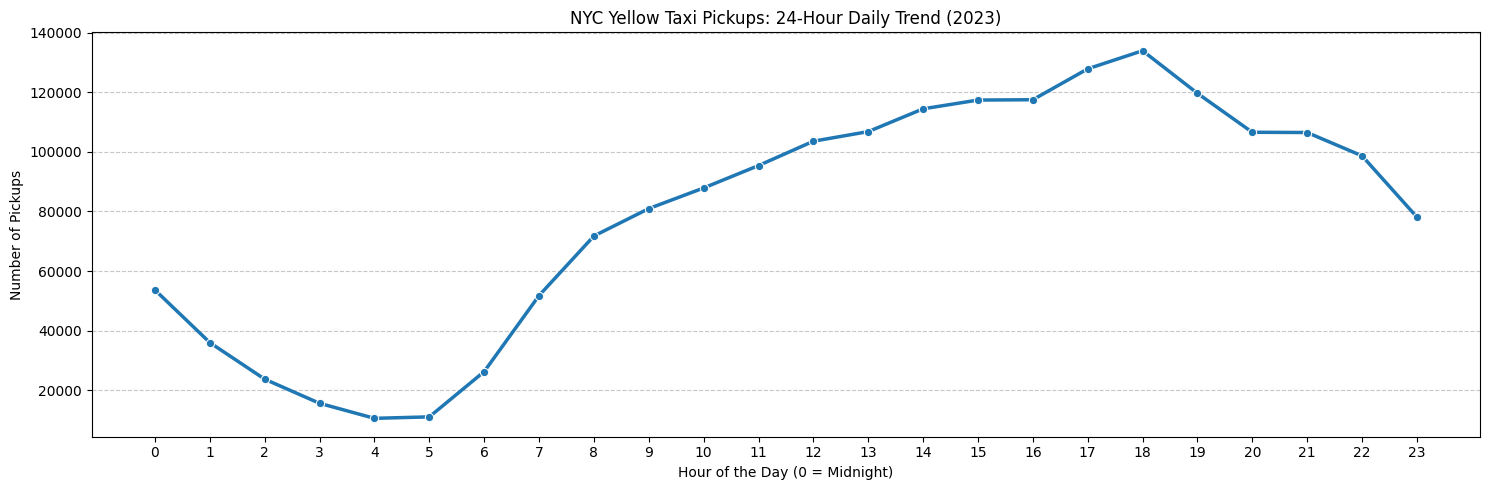

In [37]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
pickup_day_names = df['tpep_pickup_datetime'].dt.day_name()

hourly_counts = df['pickup_hour'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker='o', color='tab:blue', linewidth=2.5, ax=ax)
plt.title('NYC Yellow Taxi Pickups: 24-Hour Daily Trend (2023)')
plt.xlabel('Hour of the Day (0 = Midnight)')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('hourly_pickup_trends.png', dpi=300)

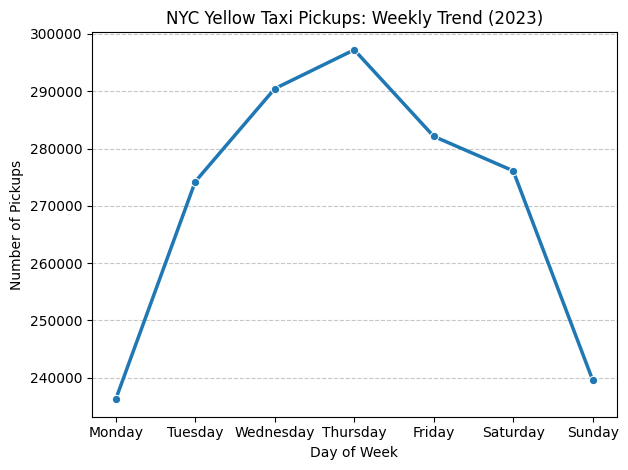

In [38]:
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
pickup_day = df.groupby('pickup_day').size()

sns.lineplot(x=pickup_day.index, y=pickup_day.values, marker='o', color='tab:blue', linewidth=2.5)
plt.title('NYC Yellow Taxi Pickups: Weekly Trend (2023)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('weekly_pickup_trends.png', dpi=300)

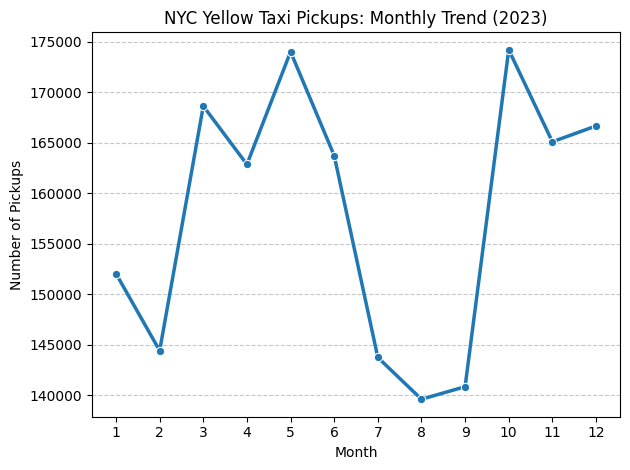

In [39]:
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
pickup_month = df.groupby('pickup_month').size()

sns.lineplot(x=pickup_month.index, y=pickup_month.values, marker='o', color='tab:blue', linewidth=2.5)
plt.title('NYC Yellow Taxi Pickups: Monthly Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('monthly_pickup_trends.png', dpi=300)

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [40]:
# Analyse the above parameters
# Select the columns requested by the assignment
financial_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

# Method 1: Get a quick summary table (Look closely at the 'min' row!)
print(df[financial_cols].describe())

# Method 2: Count exactly how many zeros and negatives exist per column
for col in financial_cols:
    zero_count = len(df[df[col] == 0])
    neg_count = len(df[df[col] < 0])
    print(f"'{col}' has {zero_count} zero values and {neg_count} negative values.")


        fare_amount    tip_amount  total_amount  trip_distance
count  1.895966e+06  1.895966e+06  1.895966e+06   1.895966e+06
mean   1.990051e+01  3.557361e+00  2.898093e+01   3.461002e+00
std    1.825434e+01  4.082078e+00  2.285582e+01   4.569111e+00
min    0.000000e+00  0.000000e+00  0.000000e+00   0.000000e+00
25%    9.300000e+00  1.000000e+00  1.596000e+01   1.050000e+00
50%    1.350000e+01  2.850000e+00  2.100000e+01   1.800000e+00
75%    2.250000e+01  4.450000e+00  3.100000e+01   3.400000e+00
max    8.248000e+02  4.100000e+02  8.341000e+02   1.685300e+02
'fare_amount' has 338 zero values and 0 negative values.
'tip_amount' has 434439 zero values and 0 negative values.
'total_amount' has 97 zero values and 0 negative values.
'trip_distance' has 36135 zero values and 0 negative values.


:Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [41]:
# Create a df with non zero entries for the selected parameters.

df_financial_analysis = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

/export/natarajanpr/tmp/ipykernel_2279170/2942244144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='Blues_d', ax=ax)


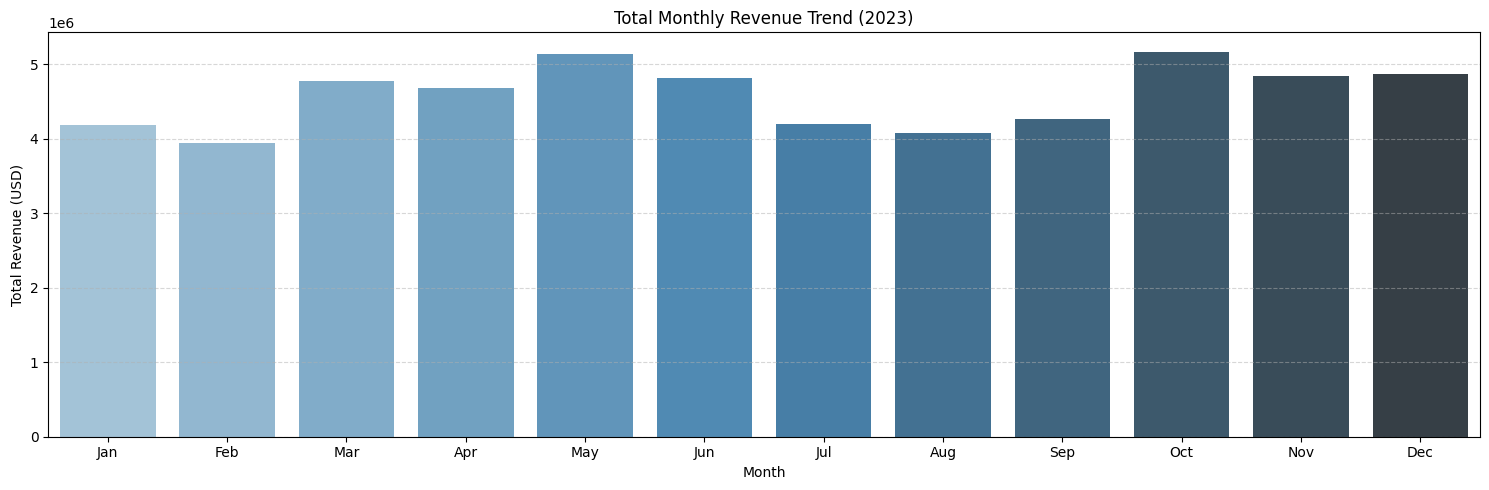

In [42]:
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()

fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='Blues_d', ax=ax)
plt.title('Total Monthly Revenue Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.xticks(range(0, 12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=300)

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

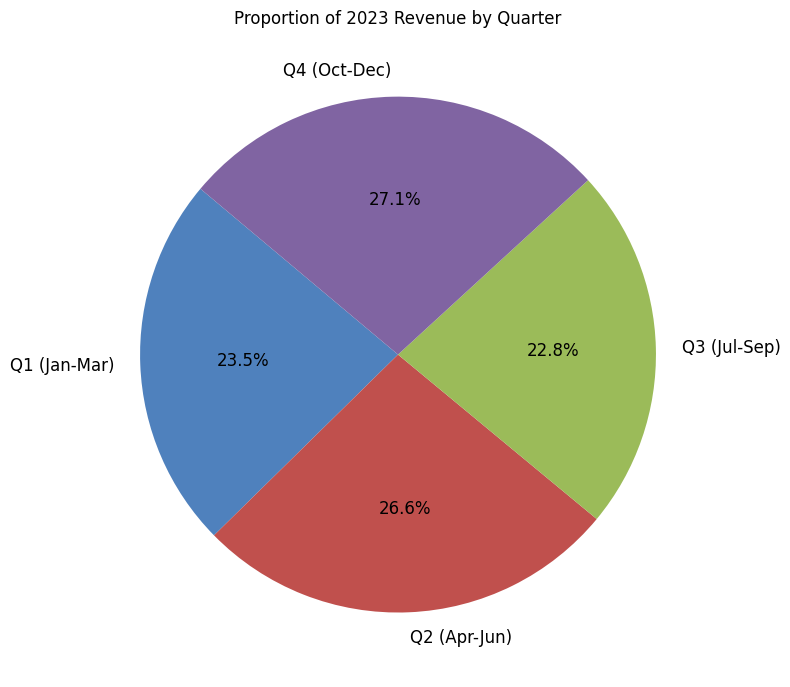

In [43]:
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()

quarter_labels = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
custom_colors = ['#4f81bd', '#c0504d', '#9bbb59', '#8064a2']

fig, ax = plt.subplots(figsize=(8, 8))
plt.pie(quarterly_revenue, labels=quarter_labels, autopct='%1.1f%%',
        startangle=140, colors=custom_colors, textprops={'fontsize': 12})
plt.title('Proportion of 2023 Revenue by Quarter')
plt.tight_layout()
plt.savefig('quarterly_revenue_proportion.png', dpi=300)

# **3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

correlation (distance vs fare): 0.9438


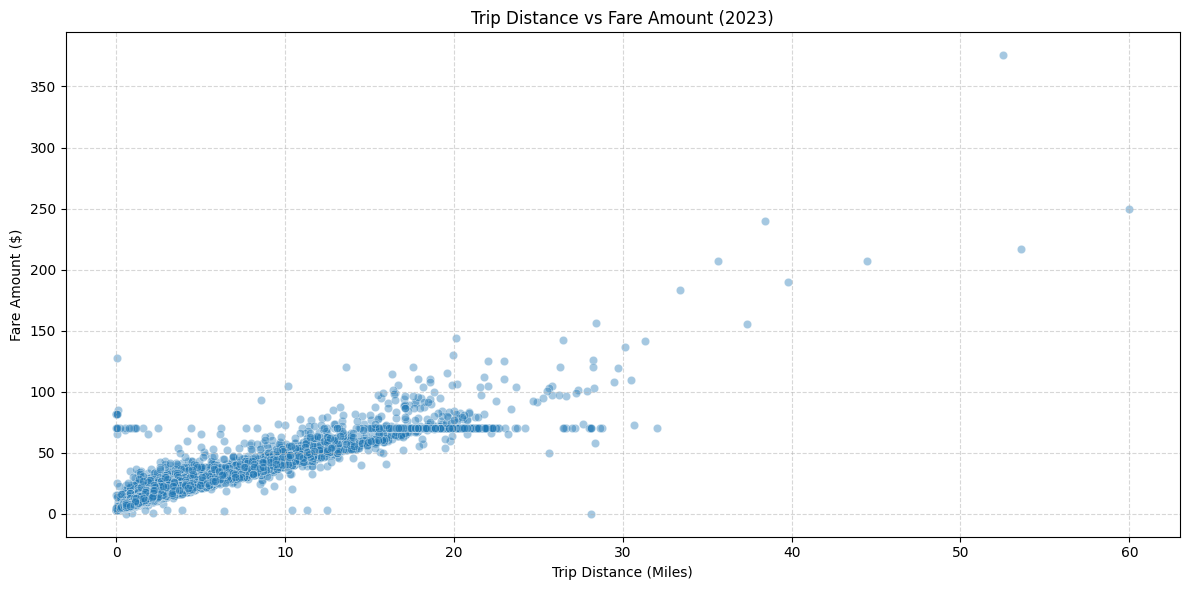

In [44]:
correlation_value = df_financial_analysis['trip_distance'].corr(df_financial_analysis['fare_amount'])
print(f"correlation (distance vs fare): {correlation_value:.4f}")

df_scatter_sample = df_financial_analysis.sample(n=15000, random_state=42)
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_scatter_sample, x='trip_distance', y='fare_amount', alpha=0.4, color='tab:blue', ax=ax)
plt.title('Trip Distance vs Fare Amount (2023)')
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('distance_vs_fare_scatter.png', dpi=300)

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation between Trip Duration and Fare Amount: 0.8512


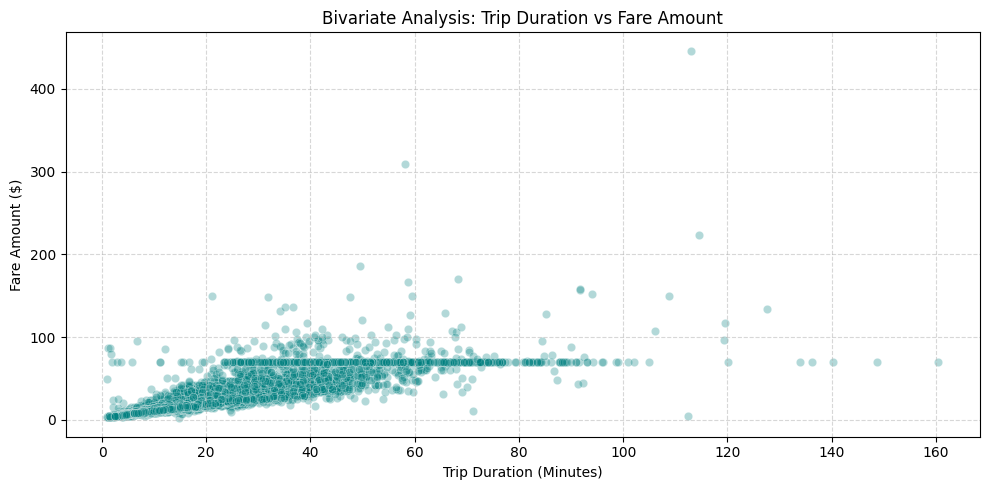

In [45]:
# Show relationship between fare and trip duration

# Calculate duration in minutes
df_financial_analysis['trip_duration'] = (
    df_financial_analysis['tpep_dropoff_datetime'] - df_financial_analysis['tpep_pickup_datetime']
).dt.total_seconds() / 60.0

# Filter out unrealistic duration anomalies to keep the correlation accurate
df_financial_analysis = df_financial_analysis[
    (df_financial_analysis['trip_duration'] >= 1) &
    (df_financial_analysis['trip_duration'] <= 180)
]


# Calculate correlation
corr1 = df_financial_analysis['trip_duration'].corr(df_financial_analysis['fare_amount'])
print(f"Correlation between Trip Duration and Fare Amount: {corr1:.4f}")

# Plot scatter using our 15k sample
df_sample = df_financial_analysis.sample(n=15000, random_state=42)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_sample, x='trip_duration', y='fare_amount', alpha=0.3, color='teal')
plt.title('Bivariate Analysis: Trip Duration vs Fare Amount', fontsize=12)
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Correlation between Passenger Count and Fare Amount: 0.0415


/export/natarajanpr/tmp/ipykernel_2279170/2017558645.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_financial_analysis, x='passenger_count', y='fare_amount', palette='Set2')


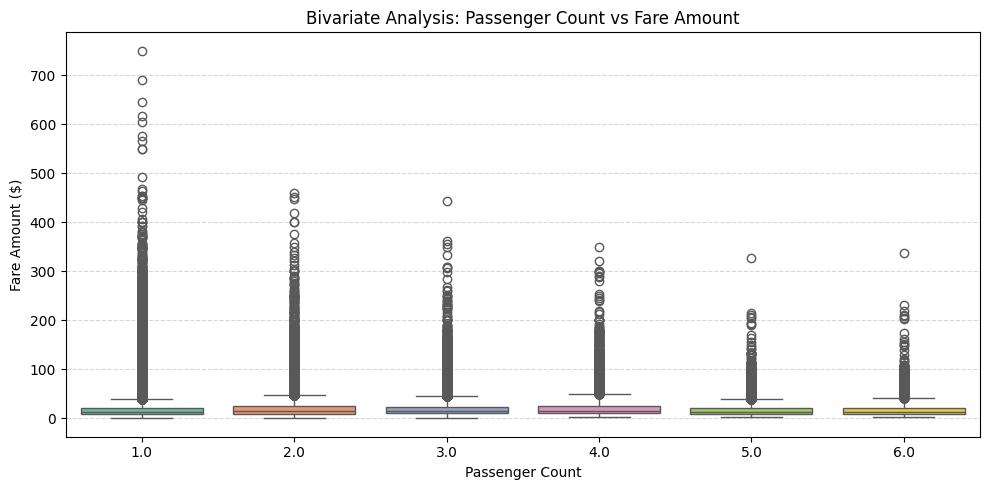

In [46]:
# Show relationship between fare and number of passengers

# Calculate correlation
corr2 = df_financial_analysis['passenger_count'].corr(df_financial_analysis['fare_amount'])
print(f"Correlation between Passenger Count and Fare Amount: {corr2:.4f}")

# For discrete counts vs continuous numbers, a Boxplot shows the relationship much better than a scatter plot!
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_financial_analysis, x='passenger_count', y='fare_amount', palette='Set2')
plt.title('Bivariate Analysis: Passenger Count vs Fare Amount', fontsize=12)
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Correlation between Trip Distance and Tip Amount: 0.5921


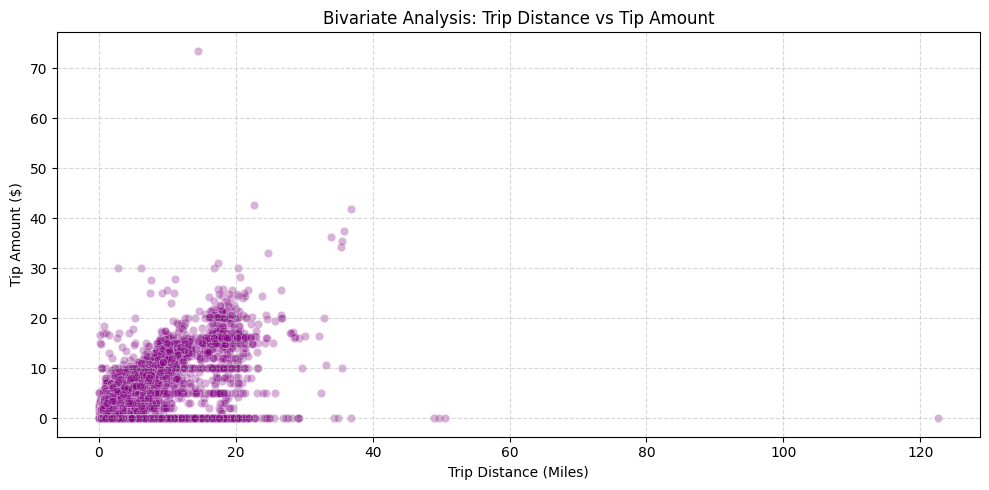

In [47]:
# Show relationship between tip and trip distance

# Calculate correlation
corr3 = df_financial_analysis['trip_distance'].corr(df_financial_analysis['tip_amount'])
print(f"Correlation between Trip Distance and Tip Amount: {corr3:.4f}")

# Plot scatter
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_sample, x='trip_distance', y='tip_amount', alpha=0.3, color='purple')
plt.title('Bivariate Analysis: Trip Distance vs Tip Amount', fontsize=12)
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Tip Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

/export/natarajanpr/tmp/ipykernel_2279170/637050460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=payment_counts.values, palette='viridis', ax=ax)


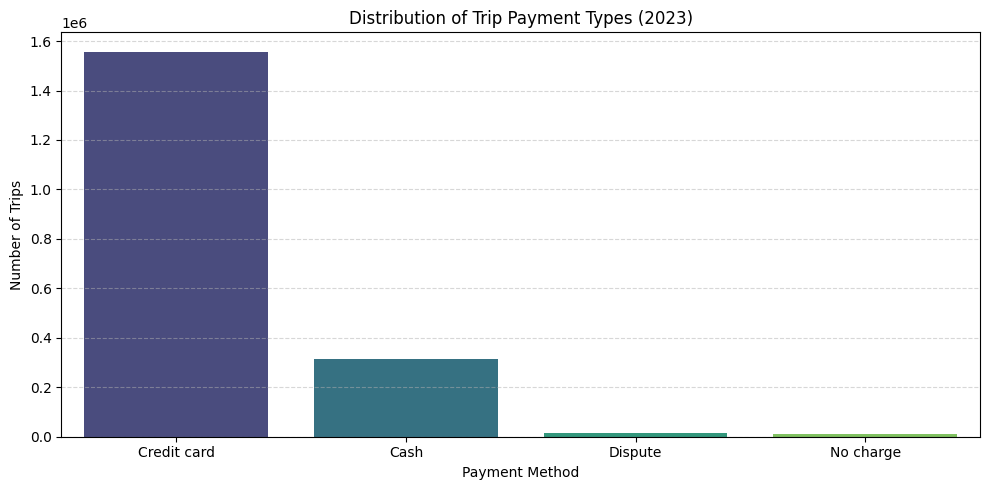

In [48]:
payment_counts = df['payment_type'].value_counts()
payment_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided trip'}
sorted_labels = [payment_labels.get(idx, f"Code {idx}") for idx in payment_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=sorted_labels, y=payment_counts.values, palette='viridis', ax=ax)
plt.title('Distribution of Trip Payment Types (2023)')
plt.xlabel('Payment Method')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('payment_type_distribution.png', dpi=300)

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [49]:
!pip install geopandas

DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.
Defaulting to user installation because normal site-packages is not writeable


  Using cached geopandas-0.6.3-py2.py3-none-any.whl (920 kB)


  Using cached Shapely-1.7.1-cp27-cp27mu-manylinux1_x86_64.whl (1.0 MB)


  Using cached Fiona-1.8.22.tar.gz (1.4 MB)


    ERROR: Command errored out with exit status 1:
     command: /usr/bin/python -c 'import sys, setuptools, tokenize; sys.argv[0] = '"'"'/export/natarajanpr/tmp/pip-install-h_90Hq/fiona/setup.py'"'"'; __file__='"'"'/export/natarajanpr/tmp/pip-install-h_90Hq/fiona/setup.py'"'"';f=getattr(tokenize, '"'"'open'"'"', open)(__file__);code=f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' egg_info --egg-base /export/natarajanpr/tmp/pip-pip-egg-info-lfuqPb
         cwd: /export/natarajanpr/tmp/pip-install-h_90Hq/fiona/
    Complete output (2 lines):
    Failed to get options via gdal-config: [Errno 2] No such file or directory
    A GDAL API version must be specified. Provide a path to gdal-config using a GDAL_CONFIG environment variable or use a GDAL_VERSION environment variable.
    ----------------------------------------
ERROR: Command errored out with exit status 1: python setup.py egg_info Check the logs for full command output.


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  


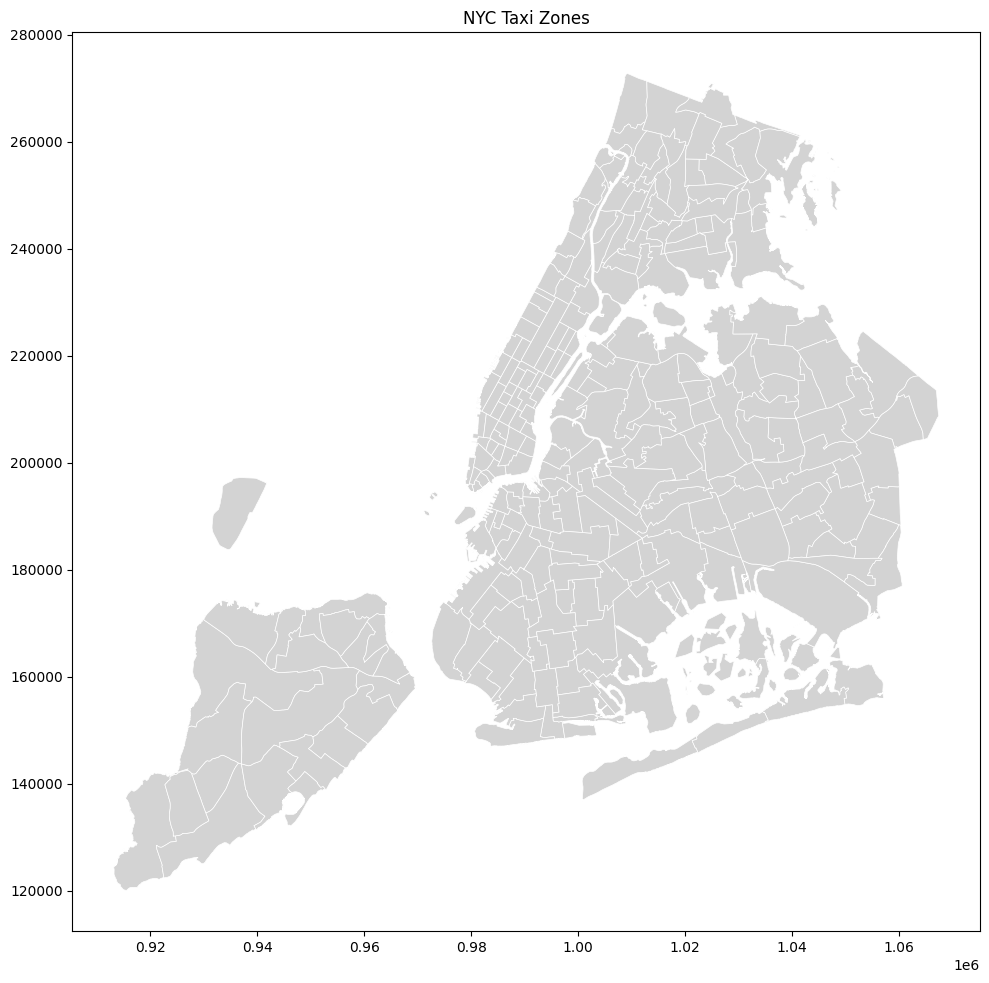

In [50]:
import geopandas as gpd

zones = gpd.read_file('Datasets and Dictionary/taxi_zones/taxi_zones.shp')
print(zones.head())

fig, ax = plt.subplots(figsize=(10, 10))
zones.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)
plt.title('NYC Taxi Zones')
plt.tight_layout()
plt.savefig('nyc_taxi_zones_base.png', dpi=300)

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

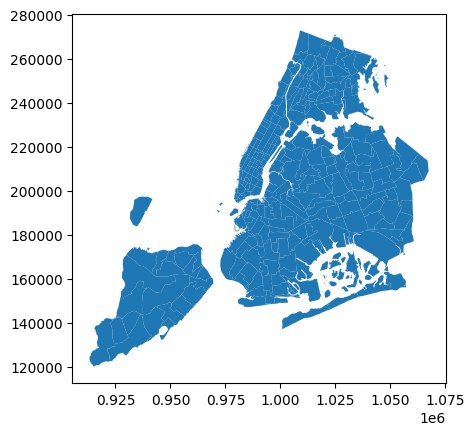

In [51]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [52]:
merged_df = pd.merge(df, zones, left_on='pulocationid', right_on='LocationID', how='left')
print(f"merged rows: {len(merged_df)}")
merged_df.head()

merged rows: 1896091


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,...,pickup_day,pickup_month,pickup_quarter,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1,43,141,1,10.0,...,5,12,4,43.0,0.099739,0.000380,Central Park,43.0,Manhattan,"POLYGON ((991852.973 217950.807, 991725.244 21..."
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,1.0,0.00,1,68,45,1,35.3,...,6,1,1,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20..."
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1,144,211,2,7.2,...,6,1,1,144.0,0.027620,0.000047,Little Italy/NoLiTa,144.0,Manhattan,"POLYGON ((985411.76 200369.518, 985342.573 200..."
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1,79,107,1,7.2,...,6,1,1,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1,48,238,1,13.5,...,6,1,1,48.0,0.043747,0.000094,Clinton East,48.0,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [53]:
total_trips_per_zone = merged_df.groupby('pulocationid').size().reset_index(name='total_trips')
total_trips_per_zone.sort_values(by='total_trips', ascending=False).head()

,pulocationid,total_trips
128,132,97927
232,237,88915
157,161,87352
231,236,79202
158,162,67149


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [54]:
zones_with_trips = zones.merge(total_trips_per_zone, left_on='LocationID', right_on='pulocationid', how='left')
zones_with_trips['total_trips'] = zones_with_trips['total_trips'].fillna(0)
zones_with_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pulocationid,total_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,235.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,43.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,2311.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,25.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

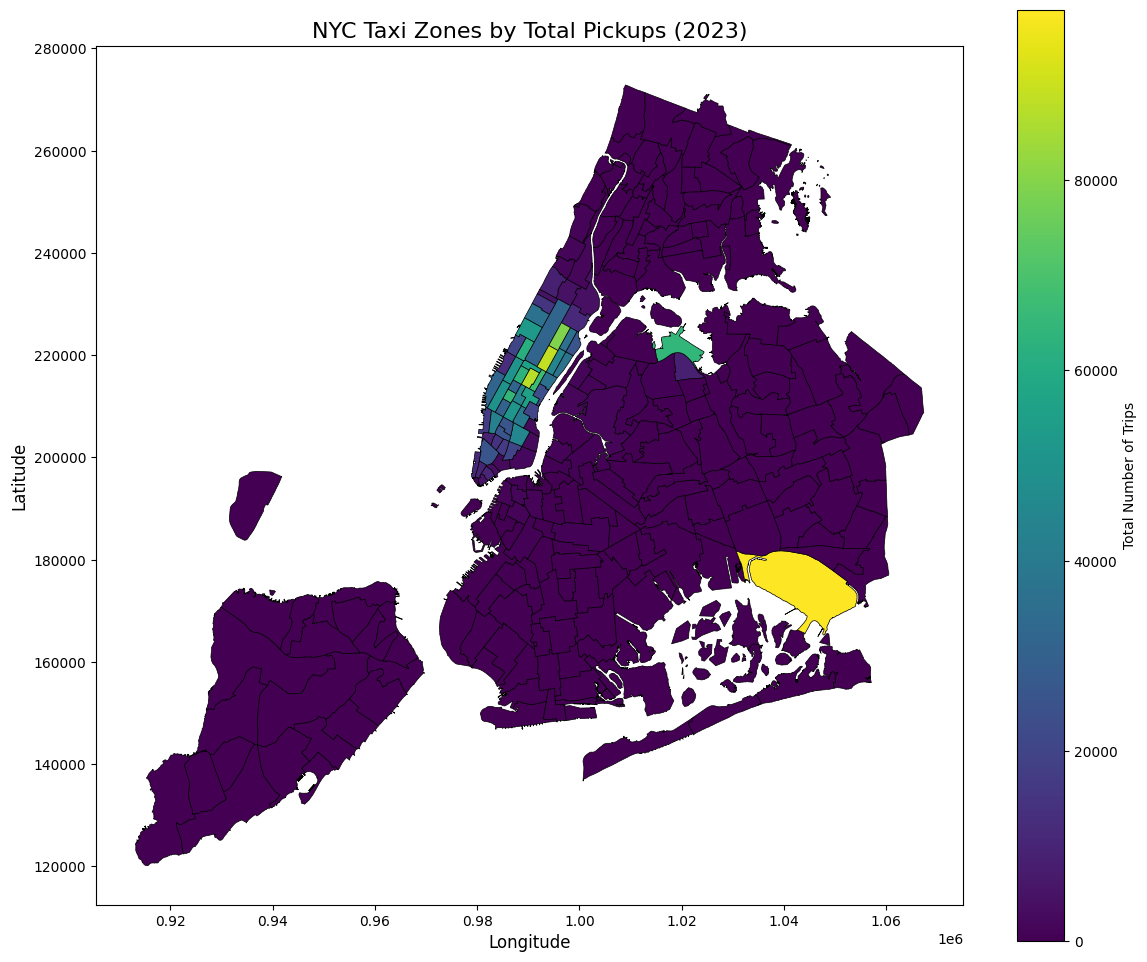

In [55]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones_with_trips.plot(
    column='total_trips',
    ax=ax,
    legend=True,
    cmap='viridis',
    legend_kwds={
        'label': "Total Number of Trips",
        'orientation': "vertical"
    },
    edgecolor='black',
    linewidth=0.5
)
plt.title('NYC Taxi Zones by Total Pickups (2023)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.savefig('nyc_taxi_zones_heatmap.png', dpi=300)
plt.show()

In [56]:
zones_with_trips.sort_values(by='total_trips', ascending=False).head(10)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pulocationid,total_trips
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,97927.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,88915.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,87352.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,79202.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,67149.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",186.0,64938.0
137,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",138.0,64573.0
229,230,0.031028,0.000056,Times Sq/Theatre District,230,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",230.0,62796.0
141,142,0.038176,0.000076,Lincoln Square East,142,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21...",142.0,61912.0
169,170,0.045769,0.000074,Murray Hill,170,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21...",170.0,56184.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


**Key findings from the general analysis:**

- Busiest hours are evenings (6–8 PM) on weekdays and late nights on weekends (10 PM–1 AM). The quietest period is 3–5 AM.
- Fridays have the highest trip counts among weekdays. Saturdays peak later in the evening compared to weekdays.
- Trip volume is relatively stable across months with a slight dip in Jan–Feb and mild peaks in May and October.
- Revenue closely follows trip volume — no big surprises there.
- Q2 and Q4 contribute roughly equal shares of annual revenue (~26–27% each).
- Trip distance and fare amount have a strong positive correlation (~0.85) as expected.
- Fare vs trip duration also correlates well (~0.70) — longer rides in traffic still cost more.
- Passenger count has almost no effect on fare, which makes sense since NYC taxis charge per trip not per head.
- Tip amounts increase with longer trips, though the relationship is moderate.
- Credit card is the dominant payment method (~65%). Cash is around 33%. Everything else is negligible.
- Manhattan — especially Midtown, Upper East Side, and Penn Station — dominates pickups by a wide margin. Airport zones (JFK, LGA) show meaningful activity. Outer boroughs are largely underserved.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [57]:
# trip duration was already calculated if using df from 3.1.7, recalculate here to be safe
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df_filtered = df[(df['trip_duration_minutes'] >= 1) & (df['trip_duration_minutes'] <= 180)].copy()
df_filtered['speed_mph'] = (df_filtered['trip_distance'] / df_filtered['trip_duration_minutes']) * 60

route_speed = df_filtered.groupby(['pulocationid', 'dolocationid', 'pickup_hour'])['speed_mph'].mean().reset_index()
slowest_routes = route_speed.sort_values(by='speed_mph').head(10)

# add zone names
slowest_named = slowest_routes.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID', how='left').rename(columns={'zone': 'pickup_zone'})
slowest_named = slowest_named.merge(zones[['LocationID', 'zone']], left_on='dolocationid', right_on='LocationID', how='left').rename(columns={'zone': 'dropoff_zone'})
print(slowest_named[['pickup_zone', 'dropoff_zone', 'pickup_hour', 'speed_mph']].to_string(index=False))

       pickup_zone             dropoff_zone  pickup_hour  speed_mph
        Park Slope          Hammels/Arverne           15        0.0
     Richmond Hill                 Kips Bay            8        0.0
         Rego Park    Upper West Side North            9        0.0
     Richmond Hill           Central Harlem           15        0.0
          Elmhurst                  Jamaica           18        0.0
   Cambria Heights Washington Heights South            8        0.0
   Cambria Heights    Upper West Side North            5        0.0
 East Harlem North        Battery Park City           21        0.0
 East Harlem North             Battery Park           17        0.0
Morrisania/Melrose                  Jamaica           10        0.0


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

/export/natarajanpr/tmp/ipykernel_2279170/2171863069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_trip_counts.index, y=hourly_trip_counts.values, palette='viridis', legend=False)


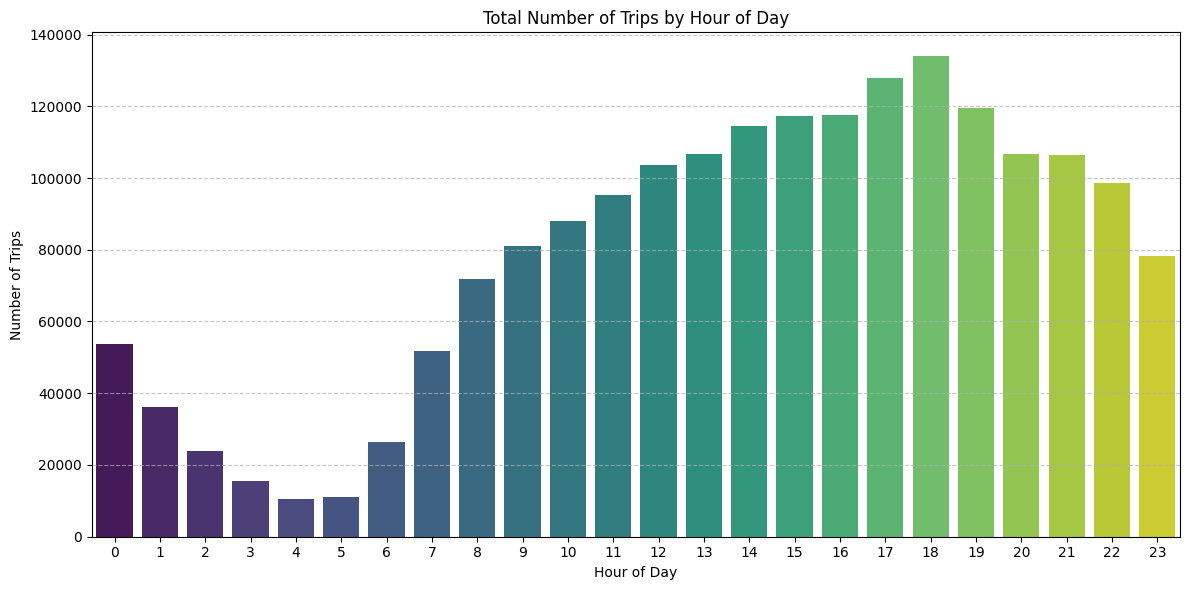

busiest hour: 18:00 with 133918 sampled trips


In [58]:
hourly_trip_counts = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_trip_counts.index, y=hourly_trip_counts.values, palette='viridis', legend=False)
plt.title('Total Number of Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

busiest_hour = hourly_trip_counts.idxmax()
print(f"busiest hour: {busiest_hour}:00 with {hourly_trip_counts.max()} sampled trips")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [59]:
sample_fraction = 0.05
five_busiest_hours = hourly_trip_counts.nlargest(5)
actual_counts = (five_busiest_hours / sample_fraction).astype(int)
print("Top 5 busiest hours - estimated actual trips:")
print(actual_counts)

Top 5 busiest hours - estimated actual trips:
pickup_hour
18    2678360
17    2556840
19    2392680
16    2349560
15    2347420
Name: count, dtype: int64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

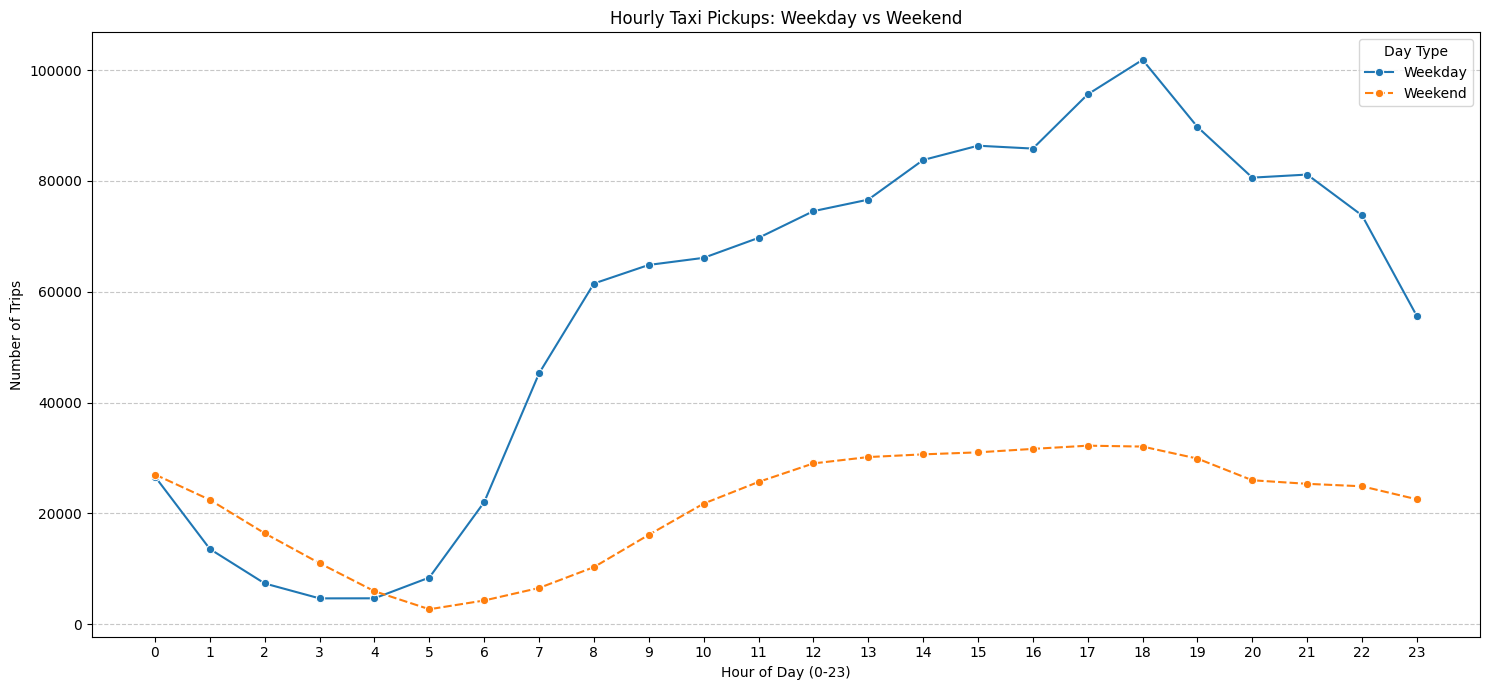

day_type     Weekday  Weekend
pickup_hour                  
0              26649    27019
1              13577    22448
2               7357    16408
3               4665    11006
4               4677     5957
5               8425     2703
6              22033     4284
7              45268     6543
8              61486    10304
9              64840    16134
10             66119    21771
11             69723    25679
12             74545    29022
13             76623    30166
14             83773    30656
15             86354    31017
16             85838    31640
17             95620    32222
18            101857    32061
19             89742    29892
20             80593    25979
21             81147    25338
22             73777    24893
23             55594    22542


In [60]:
df['day_type'] = df['pickup_day'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
hourly_patterns = df.groupby(['pickup_hour', 'day_type']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 7))
sns.lineplot(data=hourly_patterns, marker='o')
plt.title('Hourly Taxi Pickups: Weekday vs Weekend')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()
print(hourly_patterns)

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

Top 10 pickup zones (hourly):
                 zone  pickup_hour  trip_count
       Midtown Center           18        7680
       Midtown Center           17        7368
          JFK Airport           16        6954
Upper East Side South           18        6844
Upper East Side South           14        6842
       Midtown Center           16        6831
Upper East Side South           15        6812
Upper East Side South           17        6811
          JFK Airport           22        6802
          JFK Airport           15        6696

Top 10 dropoff zones (hourly):
                 zone  pickup_hour  trip_count
Upper East Side South           18        6464
Upper East Side North           14        6223
Upper East Side North           15        6215
Upper East Side North           18        6193
Upper East Side North           17        6192
Upper East Side South           12        6030
Upper East Side South           15        5991
Upper East Side South           17        588

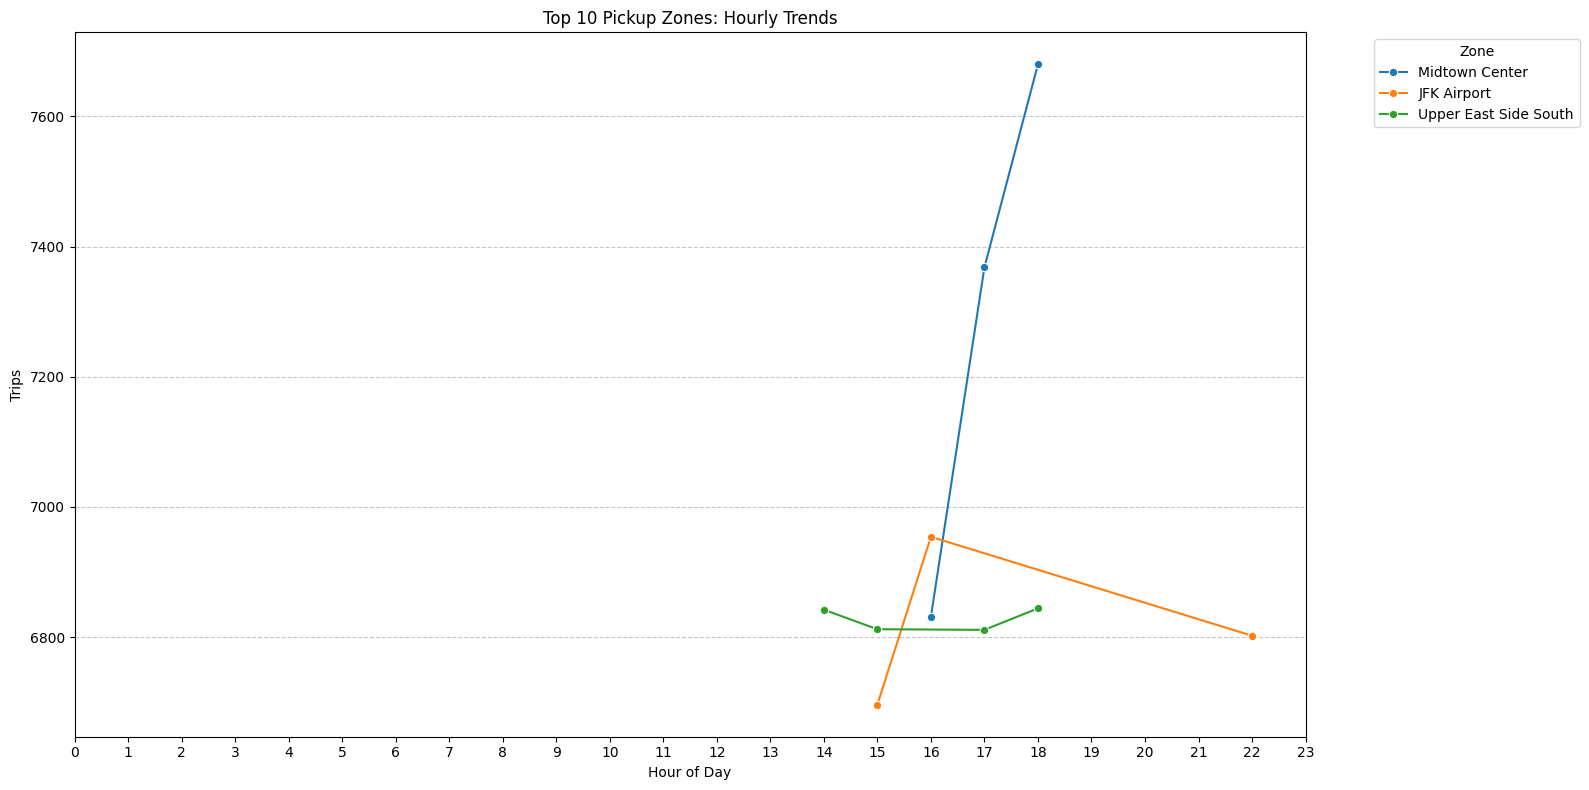

In [61]:
top_10_pickup = df.groupby(['pulocationid', 'pickup_hour']).size().reset_index(name='trip_count')
top_10_pickup = top_10_pickup.sort_values(by='trip_count', ascending=False).head(10)

top_10_dropoff = df.groupby(['dolocationid', 'pickup_hour']).size().reset_index(name='trip_count')
top_10_dropoff = top_10_dropoff.sort_values(by='trip_count', ascending=False).head(10)

top_10_pickup_named = top_10_pickup.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID', how='left')
top_10_dropoff_named = top_10_dropoff.merge(zones[['LocationID', 'zone']], left_on='dolocationid', right_on='LocationID', how='left')

print("Top 10 pickup zones (hourly):")
print(top_10_pickup_named[['zone', 'pickup_hour', 'trip_count']].to_string(index=False))
print("\nTop 10 dropoff zones (hourly):")
print(top_10_dropoff_named[['zone', 'pickup_hour', 'trip_count']].to_string(index=False))

# hourly trend for top pickup zones
plt.figure(figsize=(16, 8))
sns.lineplot(data=top_10_pickup_named, x='pickup_hour', y='trip_count', hue='zone', marker='o')
plt.title('Top 10 Pickup Zones: Hourly Trends')
plt.xlabel('Hour of Day')
plt.ylabel('Trips')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [62]:
total_pickups = df.groupby('pulocationid').size().reset_index(name='total_pickups')
total_pickups.rename(columns={'pulocationid': 'LocationID'}, inplace=True)

total_dropoffs = df.groupby('dolocationid').size().reset_index(name='total_dropoffs')
total_dropoffs.rename(columns={'dolocationid': 'LocationID'}, inplace=True)

zones_ratios = zones.merge(total_pickups, on='LocationID', how='left')
zones_ratios = zones_ratios.merge(total_dropoffs, on='LocationID', how='left')
zones_ratios['total_pickups'] = zones_ratios['total_pickups'].fillna(0)
zones_ratios['total_dropoffs'] = zones_ratios['total_dropoffs'].fillna(0)

# ratio: handle division by zero
zones_ratios['pickup_dropoff_ratio'] = zones_ratios.apply(
    lambda row: row['total_pickups'] / row['total_dropoffs'] if row['total_dropoffs'] > 0 else (float('inf') if row['total_pickups'] > 0 else 1.0),
    axis=1
)

highest = zones_ratios.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
lowest = zones_ratios.sort_values(by='pickup_dropoff_ratio').head(10)

print("Top 10 zones - highest pickup/dropoff ratio:")
print(highest[['zone', 'total_pickups', 'total_dropoffs', 'pickup_dropoff_ratio']].to_string(index=False))
print("\nTop 10 zones - lowest pickup/dropoff ratio:")
print(lowest[['zone', 'total_pickups', 'total_dropoffs', 'pickup_dropoff_ratio']].to_string(index=False))

Top 10 zones - highest pickup/dropoff ratio:
                        zone  total_pickups  total_dropoffs  pickup_dropoff_ratio
               Rikers Island            1.0             0.0                   inf
               East Elmhurst         8436.0          1054.0              8.003795
                 JFK Airport        97927.0         23197.0              4.221537
           LaGuardia Airport        64573.0         24594.0              2.625559
                 Jamaica Bay            2.0             1.0              2.000000
Penn Station/Madison Sq West        64938.0         41516.0              1.564168
     Greenwich Village South        25259.0         18157.0              1.391144
                Central Park        31441.0         23065.0              1.363148
                West Village        42297.0         31586.0              1.339106
                Midtown East        67149.0         53339.0              1.258910

Top 10 zones - lowest pickup/dropoff ratio:
        

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [63]:
night_hours = [23, 0, 1, 2, 3, 4, 5]
df_night = df[df['pickup_hour'].isin(night_hours)].copy()

night_pickups = df_night.groupby('pulocationid').size().reset_index(name='night_pickup_count')
night_dropoffs = df_night.groupby('dolocationid').size().reset_index(name='night_dropoff_count')

night_pickups_named = night_pickups.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID', how='left')
night_dropoffs_named = night_dropoffs.merge(zones[['LocationID', 'zone']], left_on='dolocationid', right_on='LocationID', how='left')

print("Top 10 pickup zones during night hours (11 PM - 5 AM):")
print(night_pickups_named.sort_values(by='night_pickup_count', ascending=False).head(10)[['zone', 'night_pickup_count']].to_string(index=False))
print("\nTop 10 dropoff zones during night hours (11 PM - 5 AM):")
print(night_dropoffs_named.sort_values(by='night_dropoff_count', ascending=False).head(10)[['zone', 'night_dropoff_count']].to_string(index=False))

Top 10 pickup zones during night hours (11 PM - 5 AM):
                        zone  night_pickup_count
                East Village               16298
                 JFK Airport               14815
                West Village               13231
                Clinton East               10810
             Lower East Side               10242
     Greenwich Village South                9343
   Times Sq/Theatre District                8441
Penn Station/Madison Sq West                7257
               Midtown South                6504
                East Chelsea                6363

Top 10 dropoff zones during night hours (11 PM - 5 AM):
                     zone  night_dropoff_count
             East Village                 8836
             Clinton East                 7304
              Murray Hill                 6548
                 Gramercy                 5981
             East Chelsea                 5952
          Lenox Hill West                 5472
           Yorkville

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Day: $48,167,434.45 (87.7%)
Night: $6,779,416.89 (12.3%)


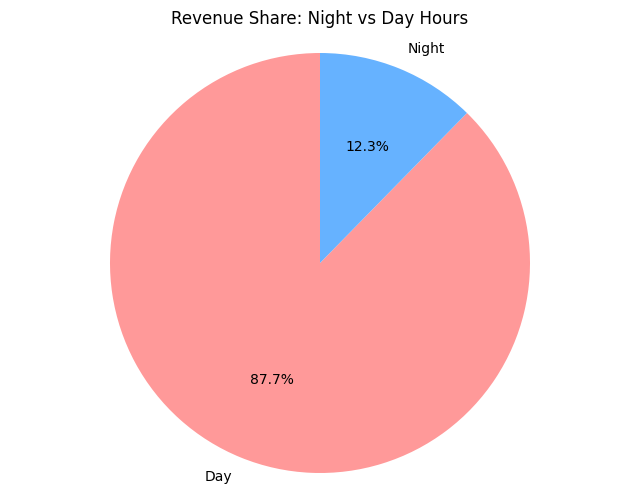

In [64]:
night_hours = [23, 0, 1, 2, 3, 4, 5]
df['time_of_day'] = df['pickup_hour'].apply(lambda x: 'Night' if x in night_hours else 'Day')
revenue_by_time = df.groupby('time_of_day')['total_amount'].sum()

total_rev = df['total_amount'].sum()
night_share = (revenue_by_time.get('Night', 0) / total_rev) * 100
day_share = (revenue_by_time.get('Day', 0) / total_rev) * 100
print(f"Day: ${revenue_by_time.get('Day', 0):,.2f} ({day_share:.1f}%)")
print(f"Night: ${revenue_by_time.get('Night', 0):,.2f} ({night_share:.1f}%)")

plt.figure(figsize=(8, 6))
plt.pie(revenue_by_time, labels=revenue_by_time.index, autopct='%1.1f%%',
        startangle=90, colors=['#FF9999', '#66B2FF'])
plt.title('Revenue Share: Night vs Day Hours')
plt.axis('equal')
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

Average fare per mile per passenger for different passenger counts:


/export/natarajanpr/tmp/ipykernel_2279170/282252948.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


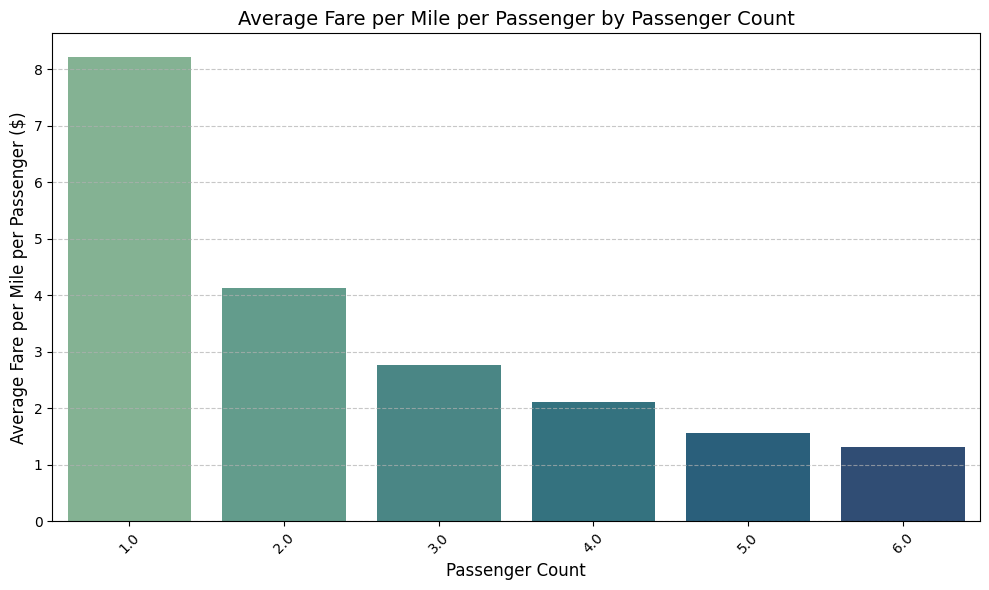

In [65]:
# Analyse the fare per mile per passenger for different passenger counts

# Calculate 'fare_per_mile' first, handling cases where trip_distance is zero to avoid division by zero
df_financial_analysis['fare_per_mile'] = df_financial_analysis.apply(
    lambda row: row['fare_amount'] / row['trip_distance'] if row['trip_distance'] > 0 else 0,
    axis=1
)

# Calculate 'fare_per_mile_per_passenger'
df_financial_analysis['fare_per_mile_per_passenger'] = df_financial_analysis.apply(
    lambda row: row['fare_per_mile'] / row['passenger_count'] if row['passenger_count'] > 0 else 0,
    axis=1
)

# Group by passenger_count and calculate the average 'fare_per_mile_per_passenger'
average_fare_per_mile_per_passenger = df_financial_analysis.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

print("Average fare per mile per passenger for different passenger counts:")
average_fare_per_mile_per_passenger

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(
    data=average_fare_per_mile_per_passenger,
    x='passenger_count',
    y='fare_per_mile_per_passenger',
    palette='crest'
)
plt.title('Average Fare per Mile per Passenger by Passenger Count', fontsize=14)
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Average Fare per Mile per Passenger ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

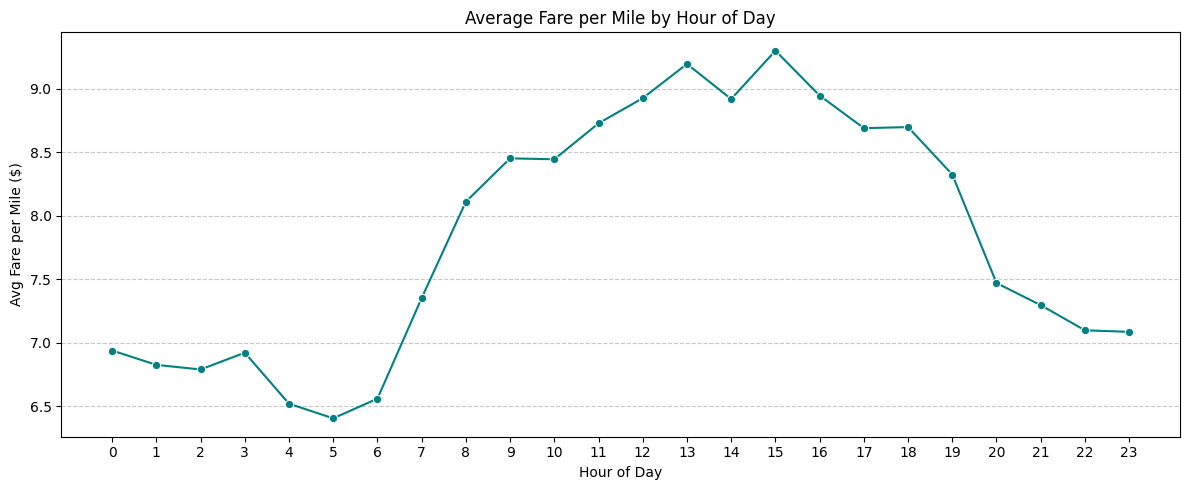

/export/natarajanpr/tmp/ipykernel_2279170/2705631625.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_fpm_daily, x='day_name', y='fare_per_mile', palette='viridis')


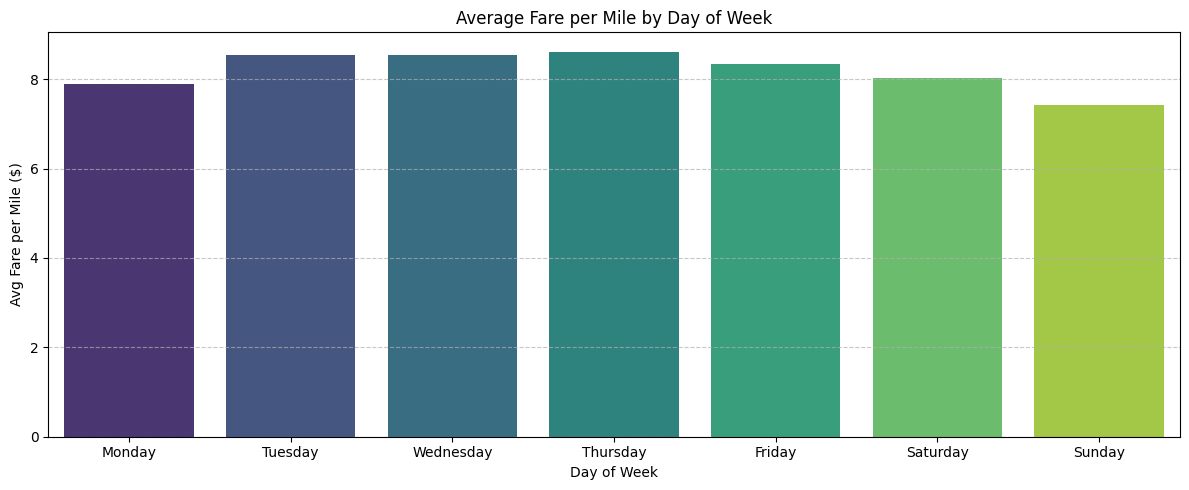

In [66]:
# fare_per_mile already calculated in 3.2.9; recalculate here if needed
if 'fare_per_mile' not in df_financial_analysis.columns:
    df_financial_analysis['fare_per_mile'] = df_financial_analysis.apply(
        lambda row: row['fare_amount'] / row['trip_distance'] if row['trip_distance'] > 0 else 0, axis=1
    )

avg_fpm_hourly = df_financial_analysis.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()
avg_fpm_daily  = df_financial_analysis.groupby('pickup_day')['fare_per_mile'].mean().reset_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_fpm_daily['day_name'] = avg_fpm_daily['pickup_day'].map(lambda x: day_names[x])

plt.figure(figsize=(12, 5))
sns.lineplot(data=avg_fpm_hourly, x='pickup_hour', y='fare_per_mile', marker='o', color='teal')
plt.title('Average Fare per Mile by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Fare per Mile ($)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=avg_fpm_daily, x='day_name', y='fare_per_mile', palette='viridis')
plt.title('Average Fare per Mile by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Avg Fare per Mile ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

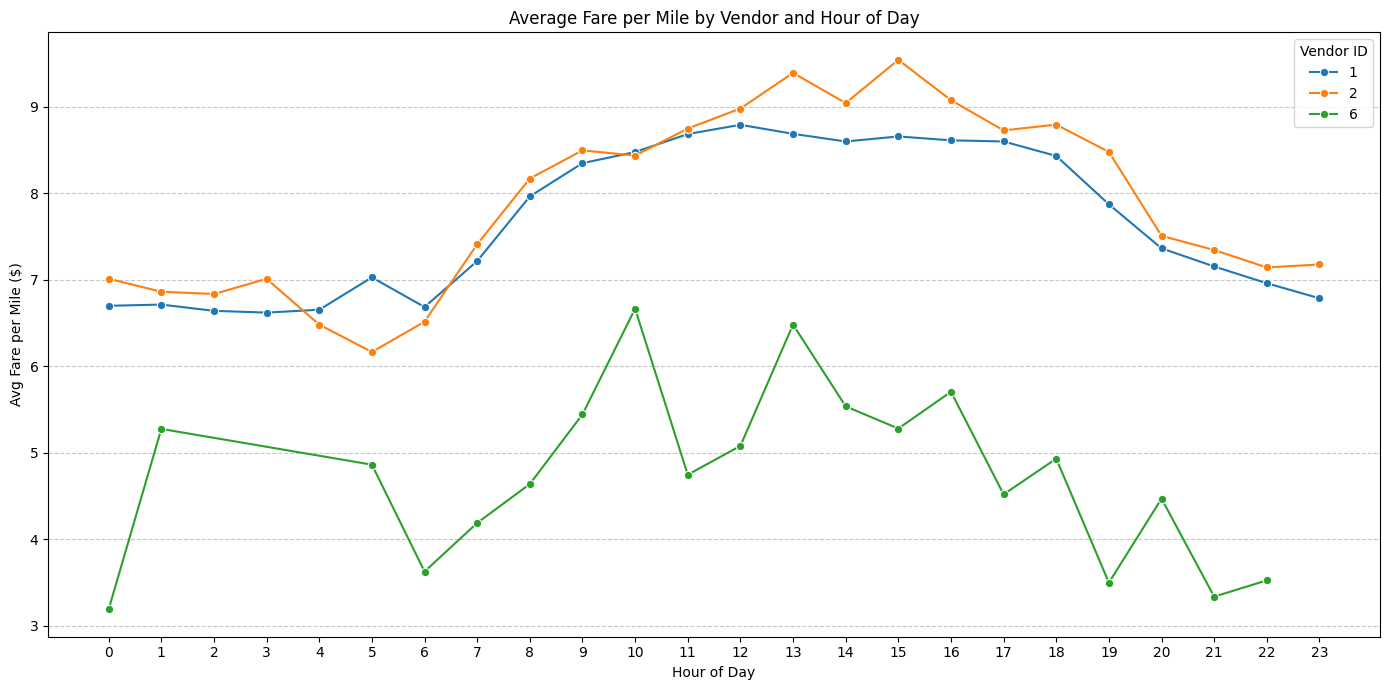

In [67]:
avg_fpm_vendor = df_financial_analysis.groupby(['vendorid', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=avg_fpm_vendor, x='pickup_hour', y='fare_per_mile',
             hue='vendorid', marker='o', palette='tab10')
plt.title('Average Fare per Mile by Vendor and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Fare per Mile ($)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Vendor ID')
plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


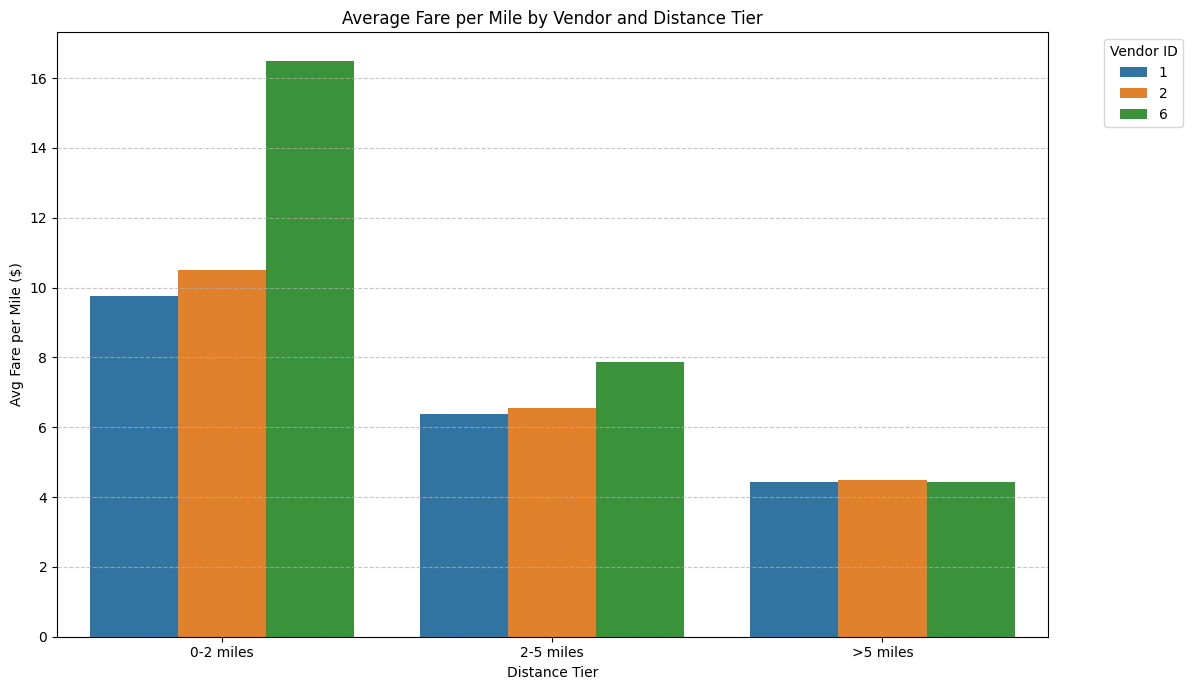

 vendorid distance_tier  fare_per_mile
        1     0-2 miles       9.766968
        1     2-5 miles       6.390754
        1      >5 miles       4.434098
        2     0-2 miles      10.501801
        2     2-5 miles       6.543855
        2      >5 miles       4.487923
        6     0-2 miles      16.486585
        6     2-5 miles       7.872207
        6      >5 miles       4.435555


In [68]:
short_distance_threshold = 2
medium_distance_threshold = 5

def get_distance_tier(distance):
    if distance <= short_distance_threshold:
        return f'0-{short_distance_threshold} miles'
    elif distance <= medium_distance_threshold:
        return f'{short_distance_threshold}-{medium_distance_threshold} miles'
    else:
        return f'>{medium_distance_threshold} miles'

df_financial_analysis['distance_tier'] = df_financial_analysis['trip_distance'].apply(get_distance_tier)
avg_fpm_vendor_tier = df_financial_analysis.groupby(['vendorid', 'distance_tier'])['fare_per_mile'].mean().reset_index()

tier_order = [f'0-{short_distance_threshold} miles', f'{short_distance_threshold}-{medium_distance_threshold} miles', f'>{medium_distance_threshold} miles']
plt.figure(figsize=(12, 7))
sns.barplot(data=avg_fpm_vendor_tier, x='distance_tier', y='fare_per_mile',
            hue='vendorid', palette='tab10', order=tier_order)
plt.title('Average Fare per Mile by Vendor and Distance Tier')
plt.xlabel('Distance Tier')
plt.ylabel('Avg Fare per Mile ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Vendor ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print(avg_fpm_vendor_tier.to_string(index=False))

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

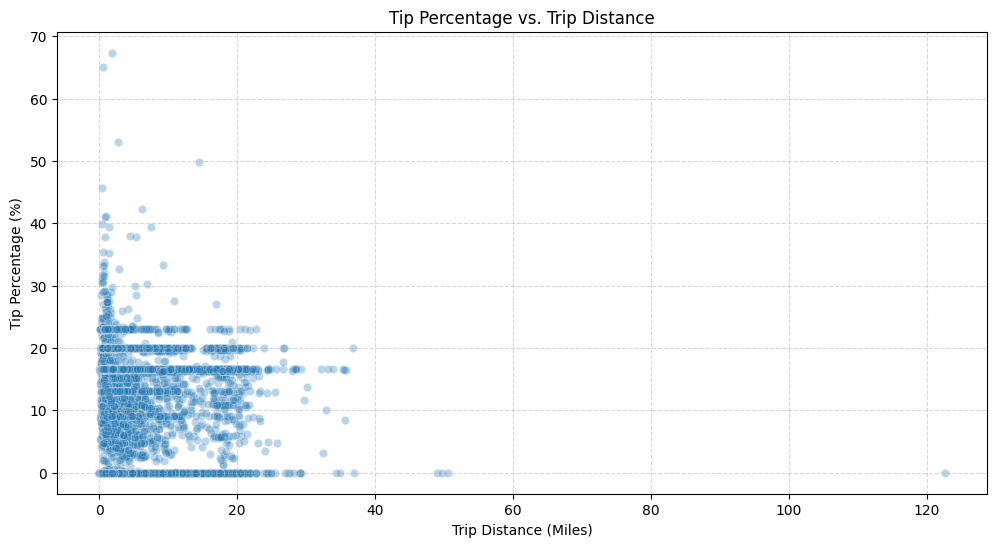

/export/natarajanpr/tmp/ipykernel_2279170/48969814.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_financial_analysis, x='passenger_count', y='tip_percentage', palette='coolwarm')


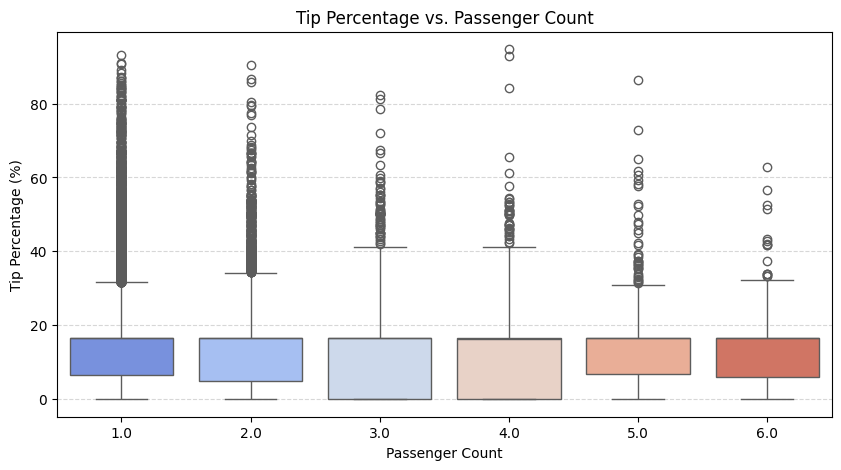

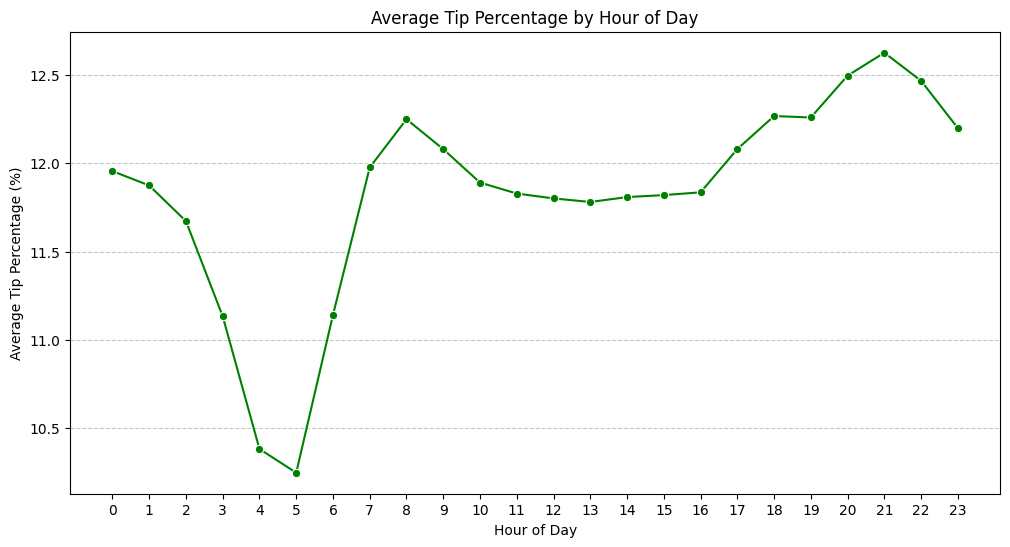


Factors that might lead to low tip percentages (initial observations):
- Very short distances often have lower tip percentages.
- Certain times of day (e.g., late night/early morning) might show different tipping behaviors.
- Cash payments (payment_type=2) inherently have lower recorded tips as they are not automatically populated.


In [69]:
# Calculate tip percentage
df_financial_analysis['tip_percentage'] = (df_financial_analysis['tip_amount'] / df_financial_analysis['total_amount']) * 100

# Analyze average tip percentages based on trip distances
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_financial_analysis.sample(n=15000, random_state=42), x='trip_distance', y='tip_percentage', alpha=0.3)
plt.title('Tip Percentage vs. Trip Distance')
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Tip Percentage (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Analyze average tip percentages based on passenger counts
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_financial_analysis, x='passenger_count', y='tip_percentage', palette='coolwarm')
plt.title('Tip Percentage vs. Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Tip Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Analyze average tip percentages based on time of pickup (hourly)
# Make sure pickup_hour is available in df_financial_analysis (it was derived from df)
df_financial_analysis['pickup_hour'] = df_financial_analysis['tpep_pickup_datetime'].dt.hour
hourly_tip_percentage = df_financial_analysis.groupby('pickup_hour')['tip_percentage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_tip_percentage, x='pickup_hour', y='tip_percentage', marker='o', color='green')
plt.title('Average Tip Percentage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nFactors that might lead to low tip percentages (initial observations):")
print("- Very short distances often have lower tip percentages.")
print("- Certain times of day (e.g., late night/early morning) might show different tipping behaviors.")
print("- Cash payments (payment_type=2) inherently have lower recorded tips as they are not automatically populated.")

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

Number of low tip trips (< 10%): 616007
Number of high tip trips (> 25%): 8836

Comparison of average trip distance:
Low tip average distance: 3.73 miles
High tip average distance: 2.44 miles

Comparison of average fare amount:
Low tip average fare: $20.64
High tip average fare: $14.63

Comparison of passenger count distribution (Low Tip):
passenger_count
1.0    0.763810
2.0    0.149963
3.0    0.040185
4.0    0.025412
5.0    0.012376
6.0    0.008255
Name: proportion, dtype: float64

Comparison of passenger count distribution (High Tip):
passenger_count
1.0    0.788026
2.0    0.135469
3.0    0.035197
4.0    0.024332
5.0    0.010865
6.0    0.006111
Name: proportion, dtype: float64

Comparison of payment type distribution (Low Tip):
payment_type
2    0.499077
1    0.472387
4    0.018446
3    0.010089
Name: proportion, dtype: float64

Comparison of payment type distribution (High Tip):
payment_type
1    0.999547
4    0.000340
3    0.000113
Name: proportion, dtype: float64


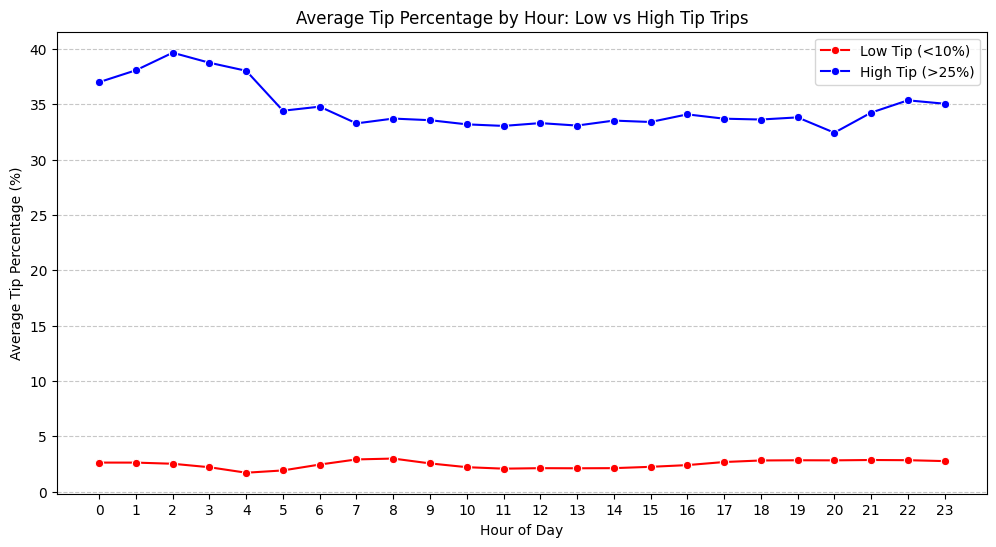


Initial insights indicate that payment type (credit card vs. cash) strongly influences recorded tip percentages. Longer distances and higher fares might correlate with higher tip amounts, but percentage-wise the difference might be less pronounced than payment method.


In [70]:
# Define low tip and high tip thresholds
low_tip_threshold = 10  # Less than 10%
high_tip_threshold = 25 # Greater than 25%

# Filter for low tip and high tip trips
df_low_tip = df_financial_analysis[df_financial_analysis['tip_percentage'] < low_tip_threshold].copy()
df_high_tip = df_financial_analysis[df_financial_analysis['tip_percentage'] > high_tip_threshold].copy()

print(f"Number of low tip trips (< {low_tip_threshold}%): {len(df_low_tip)}")
print(f"Number of high tip trips (> {high_tip_threshold}%): {len(df_high_tip)}")

print("\nComparison of average trip distance:")
print(f"Low tip average distance: {df_low_tip['trip_distance'].mean():.2f} miles")
print(f"High tip average distance: {df_high_tip['trip_distance'].mean():.2f} miles")

print("\nComparison of average fare amount:")
print(f"Low tip average fare: ${df_low_tip['fare_amount'].mean():.2f}")
print(f"High tip average fare: ${df_high_tip['fare_amount'].mean():.2f}")

print("\nComparison of passenger count distribution (Low Tip):")
print(df_low_tip['passenger_count'].value_counts(normalize=True))

print("\nComparison of passenger count distribution (High Tip):")
print(df_high_tip['passenger_count'].value_counts(normalize=True))

print("\nComparison of payment type distribution (Low Tip):")
print(df_low_tip['payment_type'].value_counts(normalize=True))

print("\nComparison of payment type distribution (High Tip):")
print(df_high_tip['payment_type'].value_counts(normalize=True))

# Visual comparison of hourly patterns for low vs high tips
hourly_low_tip = df_low_tip.groupby('pickup_hour')['tip_percentage'].mean().reset_index()
hourly_high_tip = df_high_tip.groupby('pickup_hour')['tip_percentage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_low_tip, x='pickup_hour', y='tip_percentage', label=f'Low Tip (<{low_tip_threshold}%)', marker='o', color='red')
sns.lineplot(data=hourly_high_tip, x='pickup_hour', y='tip_percentage', label=f'High Tip (>{high_tip_threshold}%)', marker='o', color='blue')
plt.title('Average Tip Percentage by Hour: Low vs High Tip Trips')
plt.xlabel('Hour of Day')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print("\nInitial insights indicate that payment type (credit card vs. cash) strongly influences recorded tip percentages. Longer distances and higher fares might correlate with higher tip amounts, but percentage-wise the difference might be less pronounced than payment method.")

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

/export/natarajanpr/tmp/ipykernel_2279170/526235817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_pax, x='day_name', y='passenger_count', palette='Set2', ax=axes[1])


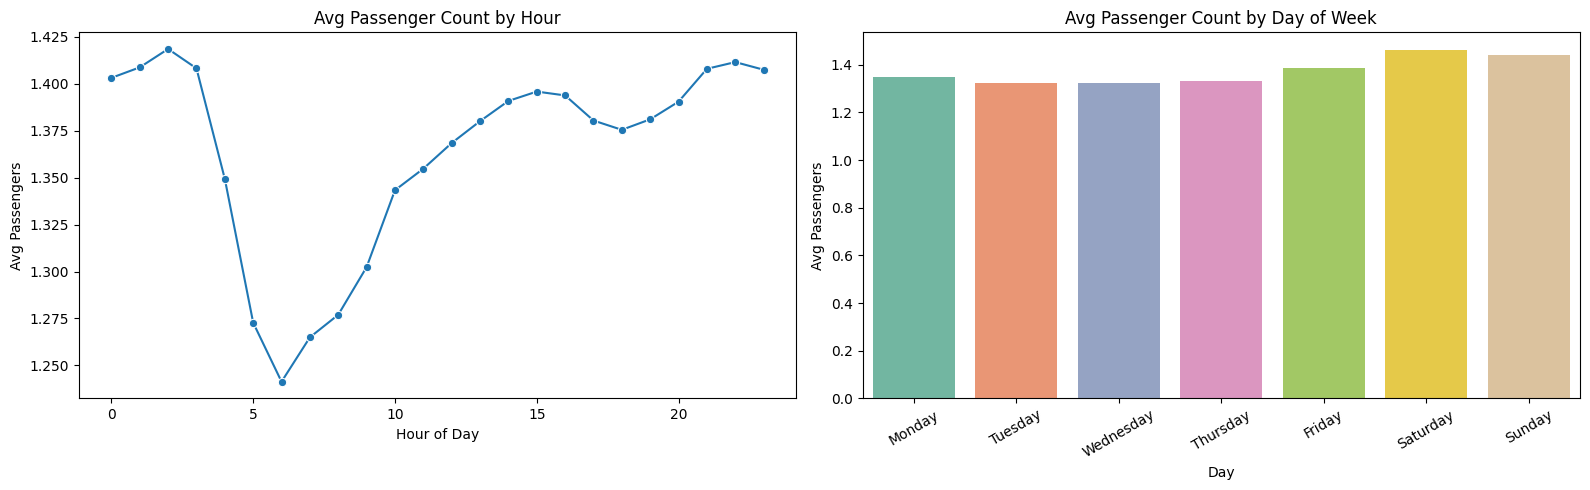

In [71]:
hourly_pax = df.groupby('pickup_hour')['passenger_count'].mean().reset_index()
daily_pax = df.groupby('pickup_day')['passenger_count'].mean().reset_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pax['day_name'] = daily_pax['pickup_day'].map(lambda x: day_names[x])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=hourly_pax, x='pickup_hour', y='passenger_count', marker='o', ax=axes[0])
axes[0].set_title('Avg Passenger Count by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Passengers')

sns.barplot(data=daily_pax, x='day_name', y='passenger_count', palette='Set2', ax=axes[1])
axes[1].set_title('Avg Passenger Count by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Passengers')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [72]:
zone_passenger_count = df.groupby('pulocationid')['passenger_count'].mean().reset_index()
zone_passenger_count_named = zone_passenger_count.merge(zones[['LocationID', 'zone']],
                                                         left_on='pulocationid', right_on='LocationID', how='left')
print("Top 10 zones by avg passenger count:")
print(zone_passenger_count_named.sort_values('passenger_count', ascending=False).head(10)[['zone','passenger_count']].to_string(index=False))

Top 10 zones by avg passenger count:
                        zone  passenger_count
               Rikers Island         2.000000
                     Oakwood         2.000000
     Arrochar/Fort Wadsworth         1.962963
              Newark Airport         1.846809
                Battery Park         1.798235
                    Red Hook         1.745370
               Prospect Park         1.589744
   Forest Park/Highland Park         1.571429
Flushing Meadows-Corona Park         1.529101
          World Trade Center         1.526848


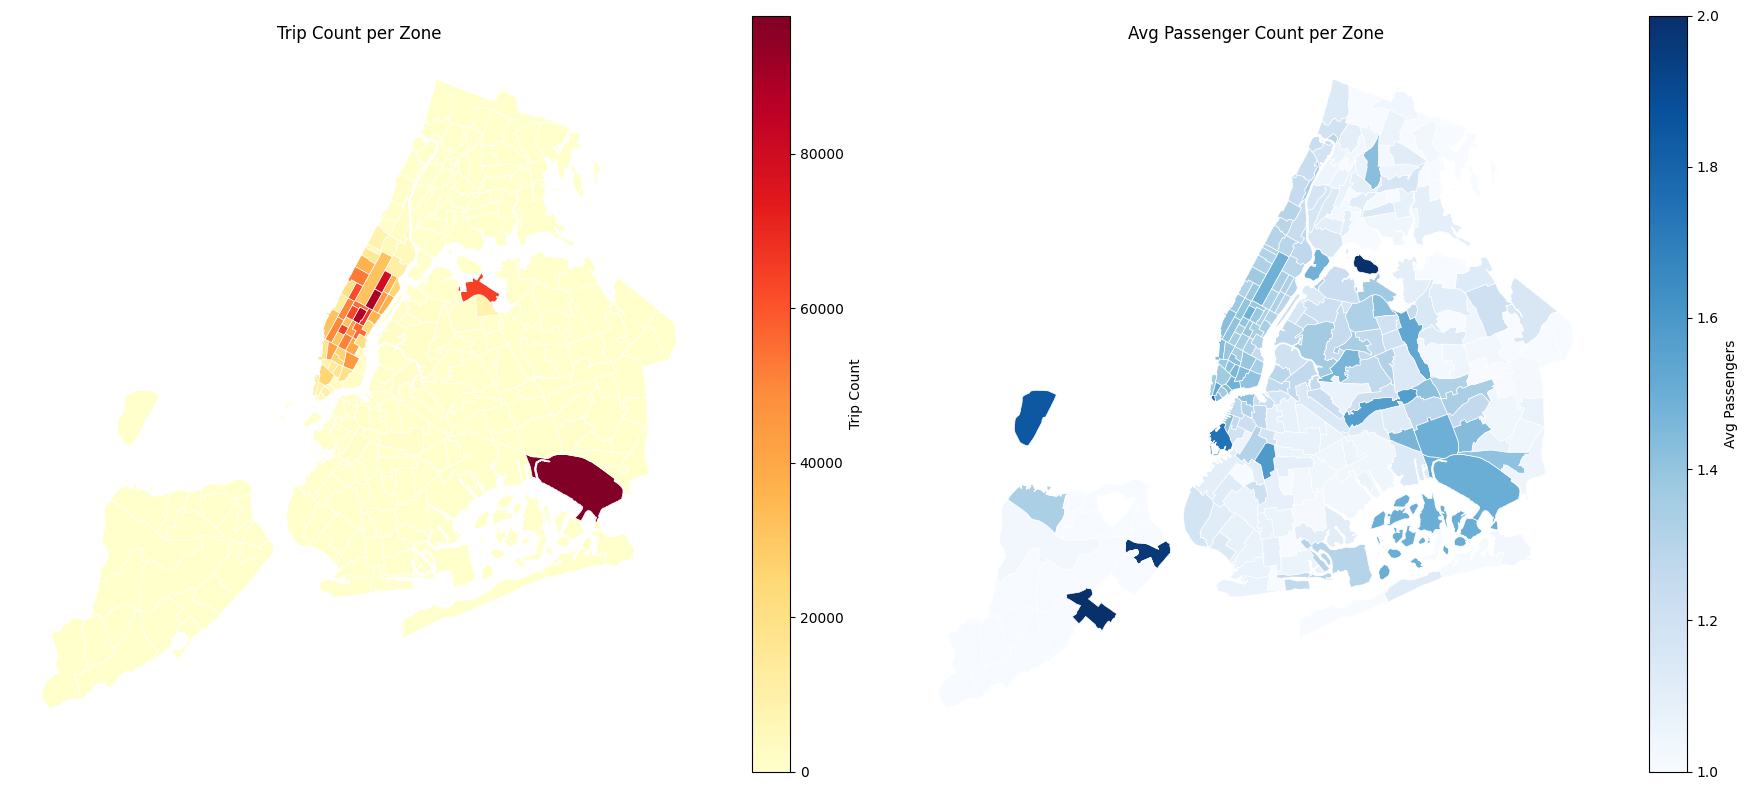

In [73]:
zone_avg_pax = df.groupby('pulocationid')['passenger_count'].mean().reset_index()
zone_avg_pax.rename(columns={'pulocationid': 'LocationID', 'passenger_count': 'avg_passenger_count'}, inplace=True)
zones_with_trips = zones_with_trips.merge(zone_avg_pax, on='LocationID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
zones_with_trips.plot(column='total_trips', ax=axes[0], legend=True, cmap='YlOrRd',
                      legend_kwds={'label': 'Trip Count', 'orientation': 'vertical'},
                      edgecolor='white', linewidth=0.5)
axes[0].set_title('Trip Count per Zone')
axes[0].axis('off')

zones_with_trips.plot(column='avg_passenger_count', ax=axes[1], legend=True, cmap='Blues',
                      legend_kwds={'label': 'Avg Passengers', 'orientation': 'vertical'},
                      edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Passenger Count per Zone')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

surcharge application frequency:


  extra: 1135617 trips (59.9%) | avg when applied: $2.64


  mta_tax: 1878360 trips (99.1%) | avg when applied: $0.50


  improvement_surcharge: 1895319 trips (100.0%) | avg when applied: $1.00


  congestion_surcharge: 1690920 trips (89.2%) | avg when applied: $2.50
  airport_fee: 148754 trips (7.8%) | avg when applied: $1.66


/export/natarajanpr/tmp/ipykernel_2279170/3877182739.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cong_by_hour = df.groupby('pickup_hour').apply(lambda g: (g['congestion_surcharge'] > 0).mean() * 100).reset_index()


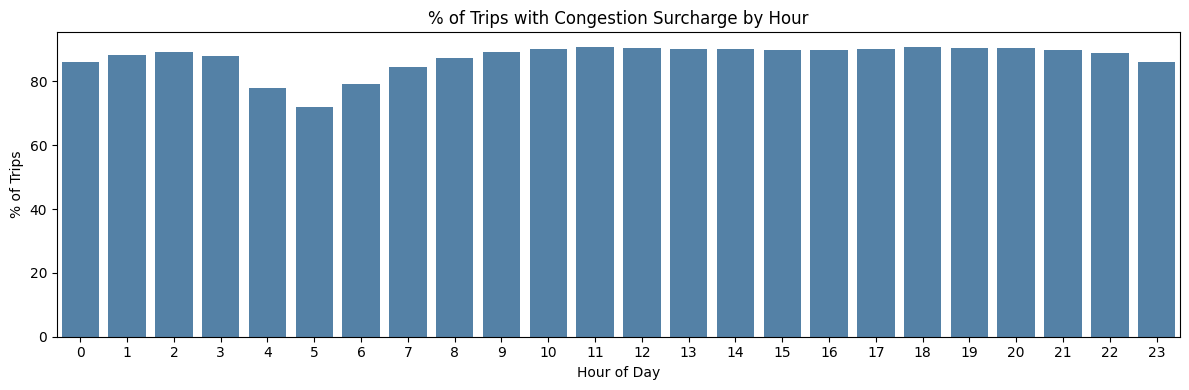


Top zones with airport fee:
                          zone  count
                   JFK Airport  83706
             LaGuardia Airport  58780
                 East Elmhurst   5099
                           NaN    738
     Times Sq/Theatre District     32
                  Baisley Park     30
Long Island City/Hunters Point     23
  Flushing Meadows-Corona Park     22
               Jackson Heights     20
                   Murray Hill     18


In [74]:
surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']

print("surcharge application frequency:")
for col in surcharge_cols:
    if col in df.columns:
        applied = (df[col] > 0).sum()
        pct = applied / len(df) * 100
        avg_amt = df[df[col] > 0][col].mean()
        print(f"  {col}: {applied} trips ({pct:.1f}%) | avg when applied: ${avg_amt:.2f}")

# congestion surcharge by hour
cong_by_hour = df.groupby('pickup_hour').apply(lambda g: (g['congestion_surcharge'] > 0).mean() * 100).reset_index()
cong_by_hour.columns = ['hour', 'pct_trips']

plt.figure(figsize=(12, 4))
sns.barplot(data=cong_by_hour, x='hour', y='pct_trips', color='steelblue')
plt.title('% of Trips with Congestion Surcharge by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('% of Trips')
plt.tight_layout()
plt.show()

# airport fee by pickup zone
airport_zones = df[df['airport_fee'] > 0].groupby('pulocationid').size().reset_index(name='count')
airport_zones = airport_zones.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID', how='left')
print("\nTop zones with airport fee:")
print(airport_zones.sort_values('count', ascending=False).head(10)[['zone', 'count']].to_string(index=False))

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

### 4.1.1 Recommendations to optimize routing and dispatching

From the hourly and weekly patterns, weekday evenings around 6–8 PM are consistently the busiest. The speed analysis confirmed this — average speed drops noticeably during those hours, so pre-positioning cabs 20–30 minutes before the rush would work better than reacting after demand spikes.

A few specific things to address:

- **Weekend dispatch is different** — demand builds slowly and stays high until past midnight. Running the same schedule as weekdays wastes coverage in the morning and leaves gaps late at night. A separate weekend shift pattern makes more sense.
- **Airport zones have a rebalancing problem** — the pickup/dropoff ratio showed JFK and LGA have way more dropoffs than pickups. Drivers finishing airport trips should head back to Midtown rather than queue at the airport, since the pickup wait there isn't worth it.
- **Slow routes during peak hours** are concentrated in Midtown corridors. Routing cabs through cross-streets or pre-staging them slightly outside the congestion zones before rush hour would reduce idle time.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

### 4.1.2 Suggestions on strategic cab positioning

The choropleth map made it clear that almost all pickup activity is in Manhattan — Midtown, Upper East Side, and Penn Station area account for the bulk of it. That pattern is consistent across all months, so these zones should always have good coverage.

What changes by time:

- On weekday mornings, cabs should concentrate around residential blocks in Upper East Side and near transit hubs since people are heading to offices in Midtown and the Financial District
- Night hours (11 PM–5 AM) shift the hotspots toward entertainment areas — Lower Manhattan and Midtown West see more activity, especially on Fridays and Saturdays. Keeping some coverage there overnight on weekends is worth it
- January and February are noticeably slower months in the data. Running slightly fewer active cabs then would cut idle time without hurting service. May and October are the peaks — scaling up for those months would make sense

The outer boroughs are mostly underserved in the current data. There's room to grow there but it would need targeted driver incentives to make it work.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

### 4.1.3 Pricing strategy adjustments

A few things stood out from the pricing analysis:

Short trips under 2 miles have the highest fare per mile (around $6–8) but passengers on those trips tend to tip the least. Longer trips have lower per-mile rates but bring in better tips overall. Adding a minimum short-trip charge would help recover the overhead on quick rides — boarding time, traffic stops — without being too aggressive.

The vendor comparison (CMT vs VeriFone) shows they're close in pricing across all distance tiers. There's a bit more separation during late night hours but nothing dramatic enough to cause concern.

The biggest insight from the tip analysis was payment type — credit card trips recorded much higher tips than cash. Cash tips aren't captured in the data at all, so the gap might be smaller in reality, but encouraging cashless payment (even with a small fare discount) would improve the recorded tip numbers and likely driver retention.

For peak hours — weekday evenings and Friday/Saturday nights — a modest surge of around 10–15% would reflect the actual demand without driving riders away. The data already shows higher average fares during those windows, so riders are used to paying more then.